<a href="https://colab.research.google.com/github/Shibli-Nomani/ML-Based-Detection-of-Trade-Mis-Invoicing-TBML-/blob/main/ML_Based_Detection_of_Trade_Mis_Invoicing_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: ML-Based Detection of Trade Mis-Invoicing (TBML)
In global trade, financial manipulation does not always happen through direct money transfers. Instead, it is often hidden inside normal looking trade
transactions. This is known as Trade Based Money Laundering (TBML).

* **Dataset Link:** [**Customs Import Declaration Datasets**](https://github.com/Seondong/Customs-Declaration-Datasets/tree/en)

* **About Dataset:** The dataset contains 54,000 synthetic import declarations with 22 features

* **Important Note:**

    * **HS6 code:**	6-digit product code (e.g., 090121 = Coffee, Roasted, Not Decaffeinated)
    * **Fraud (Target):**	Fraudulent attempt to reduce the customs duty (0/1), 0=non-fraud, 1=fraud


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import  Libraries

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# Date time utilities
import datetime as dt

# Feature scaling
from sklearn.preprocessing import StandardScaler

# Mathematical utilities
import math

# Feature engineering
from sklearn.preprocessing import PolynomialFeatures

# Classification metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    zero_one_loss,
    log_loss,
    precision_recall_curve,
    roc_curve
)

# Model pipelines
from sklearn.pipeline import make_pipeline

# Ensemble models
from sklearn.ensemble import RandomForestClassifier

# Boosting models
from xgboost import XGBClassifier

# Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# Custom scoring
from sklearn.metrics import make_scorer

import os
import pickle
import shap

# Warning management
import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [ ]:
path="/content/drive/MyDrive/PMAIDE/Sem-1/Machine Learning/Lab/Project/datasets"
df_train=pd.read_csv(path+"/df_syn_train_eng.csv")
df_val=pd.read_csv(path+"/df_syn_valid_eng.csv")
df_test=pd.read_csv(path+"/df_syn_test_eng.csv")


In [ ]:
print("Training Dataset: ")
df_train.head(3)

Training Dataset: 


,Declaration ID,Date,Office ID,Process Type,Import Type,Import Use,Payment Type,Mode of Transport,Declarant ID,Importer ID,...,HS6 Code,Country of Departure,Country of Origin,Tax Rate,Tax Type,Country of Origin Indicator,Net Mass,Item Price,Fraud,Critical Fraud
0,97061800,2020-01-01,30,B,11,21,11,10,ZZR1LT6,QLRUBN9,...,440890,BE,BE,0.0,FEU1,G,108.0,372254.40,0,0
1,85945189,2020-01-01,40,B,11,21,11,40,SWF9S4X,7JD1S2X,...,690722,CN,CN,8.0,A,Y,11352.0,375751.20,0,0
2,77854751,2020-01-01,20,B,11,21,11,40,X4XT6P8,WI9O3I5,...,620822,CN,CN,5.2,FCN1,B,20.7,5353.02,0,0


In [ ]:
print("Validation Dataset: ")
df_val.head(3)

Validation Dataset: 


,Declaration ID,Date,Office ID,Process Type,Import Type,Import Use,Payment Type,Mode of Transport,Declarant ID,Importer ID,...,HS6 Code,Country of Departure,Country of Origin,Tax Rate,Tax Type,Country of Origin Indicator,Net Mass,Item Price,Fraud,Critical Fraud
0,56839011,2021-01-01,40,B,11,11,11,40,76NV527,SHHZGSL,...,760711,CN,CN,7.2,FCN1,E,901.2,415092.72,0,0
1,64859691,2021-01-01,20,B,11,21,11,10,IP2CUKX,H6W16WM,...,321590,HK,CN,0.0,FCN1,E,400.0,30520.00,0,0
2,99950077,2021-01-01,30,B,11,21,14,10,XCIAAPR,PCW8KX7,...,650500,CN,CN,3.2,FCN1,S,339.0,2610.30,0,0


In [ ]:
print("Testing Dataset: ")
df_test.head(3)

Testing Dataset: 


,Declaration ID,Date,Office ID,Process Type,Import Type,Import Use,Payment Type,Mode of Transport,Declarant ID,Importer ID,...,HS6 Code,Country of Departure,Country of Origin,Tax Rate,Tax Type,Country of Origin Indicator,Net Mass,Item Price,Fraud,Critical Fraud
0,41256141,2021-04-01,40,B,11,21,11,40,LPA7LKZ,Y3OM027,...,420231,IT,RO,8.0,A,G,1.0,1248.70,0,0
1,20889431,2021-04-01,20,B,11,21,11,10,NZYZ967,QBIH1EB,...,711311,TH,TH,8.0,A,Y,4.7,1365.35,0,0
2,25403940,2021-04-01,40,B,11,21,11,10,69Z0KLV,KEABR8T,...,390690,CN,CN,2.4,FCN1,G,19000.0,1105800.00,0,0


# About Dataset

In [ ]:
# Shape of Datasets
print(f"Shape of Training Dataset: {df_train.shape}")
print(f"Shape of Validation Dataset: {df_val.shape}")
print(f"Shape of Testing Dataset: {df_test.shape}")
# Percentage of data split (train/val/test)
print(f"Percentage of Training Dataset: {round(df_train.shape[0]/(df_train.shape[0]+df_val.shape[0]+df_test.shape[0])*100,2)}%")
print(f"Percentage of Validation Dataset: {round(df_val.shape[0]/(df_train.shape[0]+df_val.shape[0]+df_test.shape[0])*100,2)}%")
print(f"Percentage of Testing Dataset: {round(df_test.shape[0]/(df_train.shape[0]+df_val.shape[0]+df_test.shape[0])*100,2)}%")

Shape of Training Dataset: (37385, 22)
Shape of Validation Dataset: (8134, 22)
Shape of Testing Dataset: (8481, 22)
Percentage of Training Dataset: 69.23%
Percentage of Validation Dataset: 15.06%
Percentage of Testing Dataset: 15.71%


In [ ]:
print(f"Col consists of Null values: \n {df_train.isnull().sum()}")
print(f"Col consists of Null values: \n {df_val.isnull().sum()}")
print(f"Col consists of Null values: \n {df_test.isnull().sum()}")

Col consists of Null values: 
 Declaration ID                     0
Date                               0
Office ID                          0
Process Type                       0
Import Type                        0
Import Use                         0
Payment Type                       0
Mode of Transport                  0
Declarant ID                       0
Importer ID                        0
Seller ID                       3715
Courier ID                     30671
HS6 Code                           0
Country of Departure               0
Country of Origin                  0
Tax Rate                           0
Tax Type                           0
Country of Origin Indicator        0
Net Mass                           0
Item Price                         0
Fraud                              0
Critical Fraud                     0
dtype: int64
Col consists of Null values: 
 Declaration ID                    0
Date                              0
Office ID                         0
Pro

**Dataset Summary**

- 📌 The dataset is **moderately imbalanced**, with a **Non-Fraud to Fraud** ratio across the **training(3.61 : 1.0), validation(3.77 : 1.0), and testing(3.62 : 1.0)**.
- 📌 The **Seller ID** and **Courier ID** columns contained missing values.

In [ ]:
print(f"Total Train Non-Fraud count: {df_train['Fraud'].value_counts()[0]}")
print(f"Total Train Fraud count: {df_train['Fraud'].value_counts()[1]}")
print(f"Train Non-Fraud to Fraud Ratio: {round(df_train['Fraud'].value_counts()[0] / df_train['Fraud'].value_counts()[1], 2)} : {round(df_train['Fraud'].value_counts()[1] / df_train['Fraud'].value_counts()[1], 2)}")

print(f"Total Val Non-Fraud count: {df_val['Fraud'].value_counts()[0]}")
print(f"Total Val Fraud count: {df_val['Fraud'].value_counts()[1]}")
print(f"Val Non-Fraud to Fraud Ratio: {round(df_val['Fraud'].value_counts()[0] / df_val['Fraud'].value_counts()[1], 2)} : {round(df_val['Fraud'].value_counts()[1] / df_val['Fraud'].value_counts()[1], 2)}")


print(f"Total Test Non-Fraud count: {df_test['Fraud'].value_counts()[0]}")
print(f"Total Test Fraud count: {df_test['Fraud'].value_counts()[1]}")
print(f"Test Non-Fraud to Fraud Ratio: {round(df_test['Fraud'].value_counts()[0] / df_test['Fraud'].value_counts()[1], 2)} : {round(df_test['Fraud'].value_counts()[1] / df_test['Fraud'].value_counts()[1], 2)}")

print("df_train null counts:")
print(df_train.isnull().sum()[df_train.isnull().sum() > 0])

print("\ndf_test null counts:")
print(df_test.isnull().sum()[df_test.isnull().sum() > 0])

print("\ndf_val null counts:")
print(df_val.isnull().sum()[df_val.isnull().sum() > 0])


Total Train Non-Fraud count: 29271
Total Train Fraud count: 8114
Train Non-Fraud to Fraud Ratio: 3.61 : 1.0
Total Val Non-Fraud count: 6430
Total Val Fraud count: 1704
Val Non-Fraud to Fraud Ratio: 3.77 : 1.0
Total Test Non-Fraud count: 6646
Total Test Fraud count: 1835
Test Non-Fraud to Fraud Ratio: 3.62 : 1.0
df_train null counts:
Seller ID      3715
Courier ID    30671
dtype: int64

df_test null counts:
Seller ID      691
Courier ID    6955
dtype: int64

df_val null counts:
Seller ID      795
Courier ID    6836
dtype: int64


In [ ]:
#df_train["HS6 Code"].value_counts()
#df_val["HS6 Code"].value_counts()
#df_test["HS6 Code"].value_counts()



# Data Preprocessing and Feature Engineering

 **Data Cleaning**

- 📌 Dropped **Seller ID** and **Courier ID** due to missing values.
- 📌 Removed records where **Net Mass** or **Item Price** ≤ 0.

In [ ]:
# Clean the dataset (remove col with missing values)
# drop Seller ID and Courier ID Cols
trainset = df_train.drop(["Seller ID", "Courier ID"], axis=1)
testset = df_test.drop(["Seller ID", "Courier ID"], axis=1)
valset = df_val.drop(["Seller ID", "Courier ID"], axis=1)

# remove values which are 0
trainset = trainset[(trainset['Net Mass'] > 0) & (trainset['Item Price'] > 0)]
valset  = valset[(valset['Net Mass'] > 0) & (valset['Item Price'] > 0)]
testset = testset[(testset['Net Mass'] > 0) & (testset['Item Price'] > 0)]





## Add New Aggregation Features

**Feature Engineering Summary**

- 📌 **FreqTransactions:** Counted monthly import declarations per importer to capture unusual transaction frequency.
- 📌 **Unit Price:** Calculated as **Item Price / Net Mass** to standardize product prices across shipments.
- 📌 **Median Baseline:** Used the **median** of **non-fraudulent** transactions because it is robust to outliers and better represents normal trading behavior than the mean.
- 📌 **Log Distribution:** Applied a **log transformation** to anomaly features (`Price_Dev`, `QuantityAnomaly`, and `Transaction_Anomaly`) to reduce skewness, stabilize extreme values, and make deviations from normal behavior easier for the model to learn.
- 📌 **Country Risk Features:** Computed fraud risk scores for the **Country of Origin** and **Country of Departure** using historical fraud rates to capture location-based risk patterns.

In [ ]:
# Add aggregated features

def engineer_features(df, dataset_name, is_train=True, mappings=None):

    """Engineers fraud-detection features directly on the passed dataframe."""

    out_df = df.copy()

    # -----------------------------------------------------
    # 1. DATE PROCESSING
    # -----------------------------------------------------

    print("Original Date column type:", out_df["Date"].dtype)

    out_df["Date"] = pd.to_datetime(out_df["Date"], errors="coerce")

    print("Converted Date column type:", out_df["Date"].dtype)

    out_df["Year_Month"] = out_df["Date"].dt.to_period("M")

    # FreqTransactions:
    # Monthly declaration volume per importer.

    out_df["FreqTransactions"] = (
        out_df.groupby(["Importer ID", "Year_Month"])["Declaration ID"]
        .transform("count")
    )

    # -----------------------------------------------------
    # Unit Price:
    # Calculated cost per net mass.
    # -----------------------------------------------------

    out_df["Unit Price"] = out_df["Item Price"] / out_df["Net Mass"]

    # -----------------------------------------------------
    # GLOBAL FALLBACKS
    # -----------------------------------------------------

    if is_train:

        global_unit_price_nf = out_df.loc[
            out_df["Fraud"] == 0,
            "Unit Price"
        ].median()

        global_mass_nf = out_df.loc[
            out_df["Fraud"] == 0,
            "Net Mass"
        ].median()

        global_price_nf = out_df.loc[
            out_df["Fraud"] == 0,
            "Item Price"
        ].median()

    else:

        global_unit_price_nf = mappings["global_unit_price_nf"]
        global_mass_nf = mappings["global_mass_nf"]
        global_price_nf = mappings["global_price_nf"]

    # -----------------------------------------------------
    # 2. HS6 BASELINE
    # Median unit price of non-fraud transactions
    # -----------------------------------------------------

    if is_train:

        hs6_median = (
            out_df[out_df["Fraud"] == 0]
            .groupby("HS6 Code")["Unit Price"]
            .median()
        )

    else:

        hs6_median = mappings["hs6_median"]

    out_df["HS6_Median_NF"] = (
        out_df["HS6 Code"]
        .map(hs6_median)
        .fillna(global_unit_price_nf)
    )

    # Price_Dev:
    # Log variance from HS6 baseline price.

    out_df["Price_Dev"] = np.log(
        (
            out_df["Unit Price"] /
            out_df["HS6_Median_NF"]
        ).replace(0, np.nan)
    ).fillna(0)

    # -----------------------------------------------------
    # 3. QUANTITY ANOMALY
    # -----------------------------------------------------

    if is_train:

        hs6_mass_median_nf = (
            out_df[out_df["Fraud"] == 0]
            .groupby("HS6 Code")["Net Mass"]
            .median()
        )

    else:

        hs6_mass_median_nf = mappings["hs6_mass_median_nf"]

    mapped_mass_median = (
        out_df["HS6 Code"]
        .map(hs6_mass_median_nf)
        .fillna(global_mass_nf)
    )

    # QuantityAnomaly:
    # Log variance from expected quantity.

    out_df["QuantityAnomaly"] = np.log(
        (
            out_df["Net Mass"] /
            mapped_mass_median
        ).replace(0, np.nan)
    ).fillna(0)

    # -----------------------------------------------------
    # 4. TRANSACTION ANOMALY
    # -----------------------------------------------------

    if is_train:

        hs6_country_median_nf = (
            out_df[out_df["Fraud"] == 0]
            .groupby(
                ["HS6 Code", "Country of Origin"]
            )["Item Price"]
            .median()
        )

    else:

        hs6_country_median_nf = mappings["hs6_country_median_nf"]

    row_keys = list(
        zip(
            out_df["HS6 Code"],
            out_df["Country of Origin"]
        )
    )

    mapped_medians = pd.Series(
        row_keys,
        index=out_df.index
    ).map(hs6_country_median_nf)

    broad_fallback = (
        out_df["HS6_Median_NF"] *
        out_df["Net Mass"]
    )

    final_medians = (
        mapped_medians
        .fillna(broad_fallback)
        .fillna(global_price_nf)
        .replace(0, np.nan)
    )

    # transaction_Anomaly:
    # Log variance from country-specific baseline.

    out_df["transaction_Anomaly"] = np.log(
        (
            out_df["Item Price"] /
            final_medians
        ).replace(0, np.nan)
    ).fillna(0)

    # -----------------------------------------------------
    # 5. COUNTRY OF ORIGIN RISK
    # -----------------------------------------------------

    if is_train:

        origin_rate = (
            out_df
            .groupby("Country of Origin")["Fraud"]
            .mean()
        )

        origin_log_odds = np.log(
            (origin_rate + 1e-6) /
            (1 - origin_rate + 1e-6)
        )

    else:

        origin_log_odds = mappings["origin_log_odds"]

    # CountryOriginRisk:
    # Log-odds fraud risk by country of origin.

    out_df["CountryOriginRisk"] = (
        out_df["Country of Origin"]
        .map(origin_log_odds)
        .fillna(0)
    )

    # -----------------------------------------------------
    # 6. COUNTRY OF DEPARTURE RISK
    # -----------------------------------------------------

    if is_train:

        departure_rate = (
            out_df
            .groupby("Country of Departure")["Fraud"]
            .mean()
        )

        departure_log_odds = np.log(
            (departure_rate + 1e-6) /
            (1 - departure_rate + 1e-6)
        )

    else:

        departure_log_odds = mappings["departure_log_odds"]

    # CountryDepartureRisk:
    # Log-odds fraud risk by country of departure.

    out_df["CountryDepartureRisk"] = (
        out_df["Country of Departure"]
        .map(departure_log_odds)
        .fillna(0)
    )

    # -----------------------------------------------------
    # Dataset information
    # -----------------------------------------------------

    print("-" * 50)
    print(f"{dataset_name} dataset shape: {out_df.shape}")
    print("-" * 50)

    if is_train:

        mappings = {

            "global_unit_price_nf": global_unit_price_nf,
            "global_mass_nf": global_mass_nf,
            "global_price_nf": global_price_nf,

            "hs6_median": hs6_median,
            "hs6_mass_median_nf": hs6_mass_median_nf,
            "hs6_country_median_nf": hs6_country_median_nf,

            "origin_log_odds": origin_log_odds,
            "departure_log_odds": departure_log_odds

        }

        return out_df, mappings

    else:

        return out_df

In [ ]:
df_trainset, mappings = engineer_features(
    trainset,
    "Train",
    is_train=True
)

df_valset = engineer_features(
    valset,
    "Validation",
    is_train=False,
    mappings=mappings
)

df_testset = engineer_features(
    testset,
    "Test",
    is_train=False,
    mappings=mappings
)

Original Date column type: object
Converted Date column type: datetime64[ns]
--------------------------------------------------
Train dataset shape: (37027, 29)
--------------------------------------------------
Original Date column type: object
Converted Date column type: datetime64[ns]
--------------------------------------------------
Validation dataset shape: (8055, 29)
--------------------------------------------------
Original Date column type: object
Converted Date column type: datetime64[ns]
--------------------------------------------------
Test dataset shape: (8412, 29)
--------------------------------------------------


In [ ]:
#df_trainset = engineer_features(trainset, "df_trainset")
#df_valset = engineer_features(valset, "df_valset")
#df_testset = engineer_features(testset, "df_testset")

In [ ]:
print(f"Total Null Values in Train: {df_trainset.isnull().sum().sum()}")
print(f"Total Null Values in Val: {df_valset.isnull().sum().sum()}")
print(f"Total Null Values in Test: {df_testset.isnull().sum().sum()}")

Total Null Values in Train: 0
Total Null Values in Val: 0
Total Null Values in Test: 0


In [ ]:
#df_trainset[df_trainset["Unit Price"].isnull()][["Item Price", "Net Mass", "Unit Price", "transaction_Anomaly"]]
#df_trainset[df_trainset["transaction_Anomaly"].isnull()][["Item Price", "HS6 Code", "Country of Origin", "transaction_Anomaly", "Fraud"]]


In [ ]:
df_valset.to_csv(path+"/df_valset.csv", index=False)


In [ ]:
df_valset.columns

Index(['Declaration ID', 'Date', 'Office ID', 'Process Type', 'Import Type',
       'Import Use', 'Payment Type', 'Mode of Transport', 'Declarant ID',
       'Importer ID', 'HS6 Code', 'Country of Departure', 'Country of Origin',
       'Tax Rate', 'Tax Type', 'Country of Origin Indicator', 'Net Mass',
       'Item Price', 'Fraud', 'Critical Fraud', 'Year_Month',
       'FreqTransactions', 'Unit Price', 'HS6_Median_NF', 'Price_Dev',
       'QuantityAnomaly', 'transaction_Anomaly', 'CountryOriginRisk',
       'CountryDepartureRisk'],
      dtype='object')

# Data Visualization

In [ ]:
# Distribution Plot
def plot_fraud_distribution(df, target_col, item_list, x_col, x_label, alpha=0.4):
    """
    A unified function to plot Fraud vs Non-Fraud KDE distributions for a 2x2 grid.

    Parameters:
    -----------
    df         : pandas.DataFrame (e.g., df_trainset)
    target_col : str (The category column to group/filter by, e.g., 'HS6 Code')
    item_list  : list (The 4 category items to plot, e.g., hs_list)
    x_col      : str (The feature column to plot on the x-axis)
    x_label    : str (The display label for the x-axis)
    alpha      : float (The opacity for the KDE fills, defaults to 0.4)
    """
    # Filter by target items
    plot_df = df[df[target_col].isin(item_list)].copy()
    #row:1 and col:4
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    axes = axes.flatten()

    for i, item in enumerate(item_list):
        ax = axes[i]
        temp = plot_df[plot_df[target_col] == item]

        # Non-Fraud Distribution
        sns.kdeplot(
            data=temp[temp['Fraud'] == 0],
            x=x_col,
            fill=True,
            alpha=alpha,
            label='Non-Fraud',
            ax=ax
        )

        # Fraud Distribution
        sns.kdeplot(
            data=temp[temp['Fraud'] == 1],
            x=x_col,
            fill=True,
            alpha=alpha,
            label='Fraud',
            ax=ax,
            color='red'
        )

        # Styling and Annotations
        ax.set_title(f'{target_col}: {item}')
        ax.set_xlabel(x_label)
        ax.set_ylabel('Density')
        ax.axvline(0, color='black', linestyle='--')
        ax.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
# 1. Price Dev
#plot_fraud_distribution(df_trainset, 'HS6 Code', hs_list, 'Price_Dev', 'Log Price Deviation')

# 2. Quantity Anomaly
# plot_fraud_distribution(df_trainset, 'HS6 Code', hs_list, 'QuantityAnomaly', 'Log Quantity Anomaly')

# 3. Transaction Anomaly
# plot_fraud_distribution(df_trainset, 'HS6 Code', hs_list, 'transaction_Anomaly', 'Log Transaction Anomaly')

# 4. Country of Origin Risk
# plot_fraud_distribution(df_trainset, 'HS6 Code', hs_list, 'CountryOriginRisk', 'Country of Origin Risk (Log-Odds)')

# 5. Country of Departure Risk
# plot_fraud_distribution(df_trainset, 'HS6 Code', hs_list, 'CountryDepartureRisk', 'Country of Departure Risk (Log-Odds)')

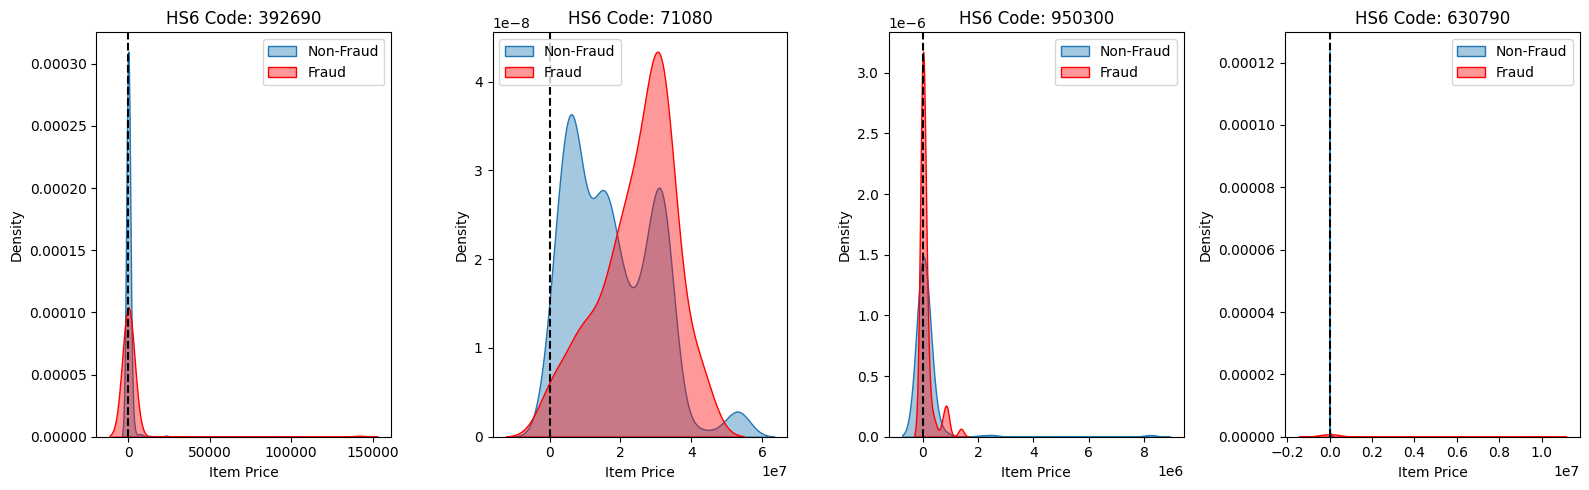

In [ ]:
# List of hscode
hs_list = [392690, 71080, 950300, 630790]
# Item Price
plot_fraud_distribution(df_trainset, 'HS6 Code', hs_list, 'Item Price', 'Item Price')

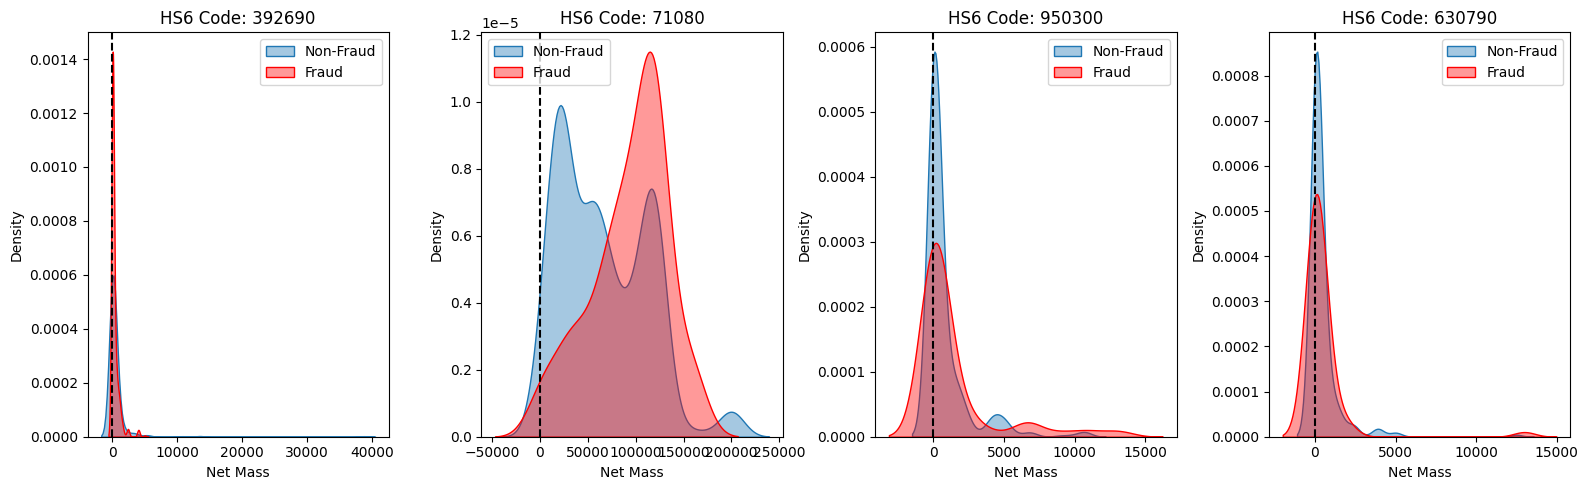

In [ ]:
# Net Mass
plot_fraud_distribution(df_trainset, 'HS6 Code', hs_list, 'Net Mass', 'Net Mass')

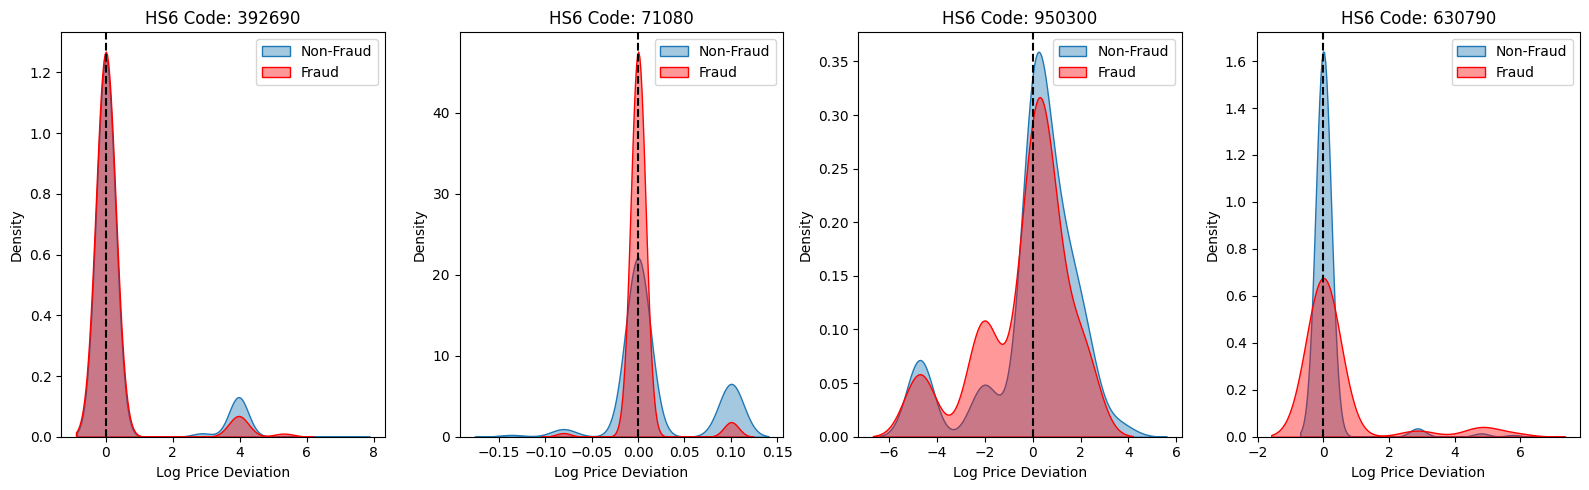

In [ ]:
# 1. Price Dev
plot_fraud_distribution(df_trainset, 'HS6 Code', hs_list, 'Price_Dev', 'Log Price Deviation')

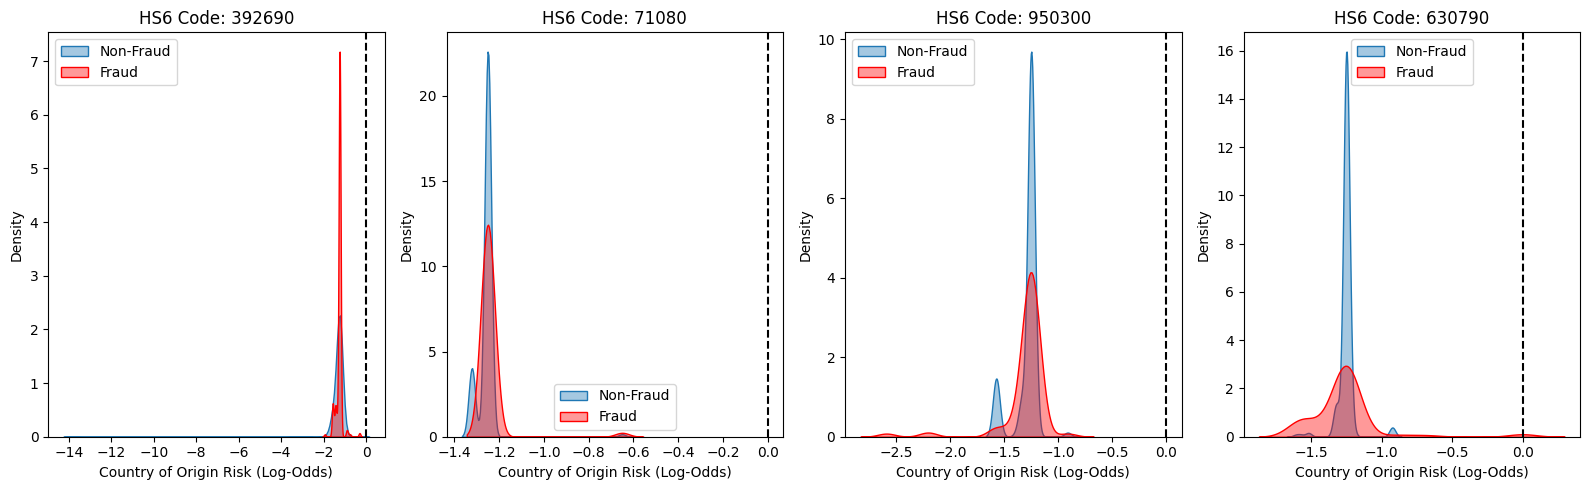

In [ ]:
# 4. Country of Origin Risk
plot_fraud_distribution(df_trainset, 'HS6 Code', hs_list, 'CountryOriginRisk', 'Country of Origin Risk (Log-Odds)')

# Feature Transformation and Normalization

In [ ]:
#df_trainset.nunique()
summary = pd.DataFrame({
    "Unique Values": df_trainset.nunique(),
    "Value Distribution (%)": [
        (df_trainset[col]
         .value_counts(normalize=True)
         .mul(100)
         .round(2)
         .to_dict())
        for col in df_trainset.columns
    ]
}, index=df_trainset.columns)

summary

#for i in ['', 'Process Type']:
  #print(f"Colwise value counts: {df_trainset[i].value_counts()}")


,Unique Values,Value Distribution (%)
Declaration ID,37027,"{46196555: 0.0, 97061800: 0.0, 85945189: 0.0, ..."
Date,366,"{2020-08-03 00:00:00: 1.16, 2020-01-10 00:00:0..."
Office ID,42,"{40: 37.21, 20: 30.48, 30: 15.77, 16: 5.07, 13..."
Process Type,3,"{'B': 99.98, 'D': 0.01, 'A': 0.0}"
Import Type,28,"{11: 86.5, 87: 4.08, 94: 3.25, 15: 1.74, 89: 1..."
Import Use,14,"{21: 91.34, 11: 4.58, 26: 2.09, 23: 0.73, 28: ..."
Payment Type,10,"{11: 67.49, 43: 18.51, 18: 6.72, 14: 5.98, 0: ..."
Mode of Transport,6,"{10: 56.68, 40: 41.15, 50: 1.59, 30: 0.36, 90:..."
Declarant ID,1220,"{'PF1L1IG': 3.51, 'DWNJQL8': 3.4, 'OZB7KED': 2..."
Importer ID,12677,"{'708A72F': 0.37, '1ZNY80M': 0.35, 'NXZGW6G': ..."


In [ ]:
#Features and Target
def get_features_target(df, cols_to_drop, target_col="Fraud", dataset="dataset"):
    df = df.copy()

    # Drop unwanted columns
    df = df.drop(columns=cols_to_drop, errors="ignore")

    # Ensure target exists
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found in dataframe")

    # Move target column to last
    cols = [c for c in df.columns if c != target_col] + [target_col]
    df = df[cols]

    # Split
    X = df.drop(columns=[target_col]).reset_index(drop=True)
    y = df[target_col].reset_index(drop=True)

    print(f"Final {dataset} shape:", df.shape)
    print(f"Features {dataset} shape:", X.shape)
    print(f"Target {dataset} shape:", y.shape)
    print(f"Null Status of {dataset}: {df.isnull().sum().sum()}")


    return X, y

In [ ]:
# Required col drops
cols_to_drop = [
    "Declaration ID",
    "Declarant ID",
    "Importer ID",
    "Date",
    "Year_Month",
    "Critical Fraud"
]

# Train, Val, Test


X_train, y_train = get_features_target(df_trainset, cols_to_drop, "Fraud", "train")
X_val, y_val = get_features_target(df_valset, cols_to_drop, "Fraud", "val")
X_test, y_test = get_features_target(df_testset, cols_to_drop, "Fraud", "test")

Final train shape: (37027, 23)
Features train shape: (37027, 22)
Target train shape: (37027,)
Null Status of train: 0
Final val shape: (8055, 23)
Features val shape: (8055, 22)
Target val shape: (8055,)
Null Status of val: 0
Final test shape: (8412, 23)
Features test shape: (8412, 22)
Target test shape: (8412,)
Null Status of test: 0


In [ ]:
X_train.nunique()

,0
Office ID,42
Process Type,3
Import Type,28
Import Use,14
Payment Type,10
Mode of Transport,6
HS6 Code,2358
Country of Departure,101
Country of Origin,116
Tax Rate,118


In [ ]:
X_val.nunique()

,0
Office ID,42
Process Type,2
Import Type,25
Import Use,13
Payment Type,9
Mode of Transport,6
HS6 Code,1629
Country of Departure,80
Country of Origin,95
Tax Rate,87


In [ ]:
X_test.nunique()

,0
Office ID,42
Process Type,2
Import Type,24
Import Use,13
Payment Type,9
Mode of Transport,6
HS6 Code,1657
Country of Departure,78
Country of Origin,92
Tax Rate,95


In [ ]:
for col in X_train.columns:
    print(col)
    print(f"X_train Describe:\n {X_train[col].describe()}")
    print(f"X_val Describe: \n {X_val[col].describe()}")
    print(f"X_test Describe: \n {X_test[col].describe()}")


Office ID
X_train Describe:
 count    37027.000000
mean        31.302428
std         16.060177
min         10.000000
25%         20.000000
50%         30.000000
75%         40.000000
max        154.000000
Name: Office ID, dtype: float64
X_val Describe: 
 count    8055.000000
mean       31.503414
std        16.637197
min        10.000000
25%        20.000000
50%        30.000000
75%        40.000000
max       154.000000
Name: Office ID, dtype: float64
X_test Describe: 
 count    8412.000000
mean       30.638730
std        15.503368
min        10.000000
25%        20.000000
50%        30.000000
75%        40.000000
max       154.000000
Name: Office ID, dtype: float64
Process Type
X_train Describe:
 count     37027
unique        3
top           B
freq      37021
Name: Process Type, dtype: object
X_val Describe: 
 count     8055
unique       2
top          B
freq      8054
Name: Process Type, dtype: object
X_test Describe: 
 count     8412
unique       2
top          B
freq      8411
Name:

In [ ]:
# Column Name

print(f"Train: {X_train.columns}")

Train: Index(['Office ID', 'Process Type', 'Import Type', 'Import Use',
       'Payment Type', 'Mode of Transport', 'HS6 Code', 'Country of Departure',
       'Country of Origin', 'Tax Rate', 'Tax Type',
       'Country of Origin Indicator', 'Net Mass', 'Item Price',
       'FreqTransactions', 'Unit Price', 'HS6_Median_NF', 'Price_Dev',
       'QuantityAnomaly', 'transaction_Anomaly', 'CountryOriginRisk',
       'CountryDepartureRisk'],
      dtype='object')


In [ ]:
# Custom Pipeline for Feature Scaling, Encoding
class CustomsDataPipeline:

    def __init__(self):

        # -------------------------
        # CATEGORICAL GROUPS
        # -------------------------

        # Low-cardinality → One-hot
        self.ohe_cols = [
            "Mode of Transport",
            "Tax Type",
            "Country of Origin Indicator",
            "Process Type",
            "Import Use"
        ]

        # High-cardinality → Frequency encoding
        self.freq_cols = [
            "Office ID",
            "Import Type",
            "Payment Type",
            "HS6 Code",
            "Country of Departure",
            "Country of Origin"
        ]

        # -------------------------
        # NUMERIC FEATURES
        # -------------------------
        self.num_cols = [
            "Tax Rate",
            "Net Mass",
            "Item Price",
            "FreqTransactions",
            "Unit Price",
            "HS6_Median_NF",
            "Price_Dev",
            "QuantityAnomaly",
            "transaction_Anomaly",
            "CountryOriginRisk",
            "CountryDepartureRisk"
        ]

        # -------------------------
        # INTERNAL STORAGE
        # -------------------------
        self.ohe_maps = {}
        self.freq_maps = {}
        self.num_medians = {}
        self.scaler = StandardScaler()
        self.final_features = []

    # =========================================================
    # FIT + TRANSFORM TRAIN
    # =========================================================
    def fit_transform(self, X):

        X = X.copy()

        # -------------------------
        # Handle infinities
        # -------------------------
        X[self.num_cols] = X[self.num_cols].replace([np.inf, -np.inf], np.nan)

        for col in self.num_cols:
            med = X[col].median()
            self.num_medians[col] = 0.0 if np.isnan(med) else med
            X[col] = X[col].fillna(self.num_medians[col])

        # -------------------------
        # ONE HOT ENCODING (FIXED MAP)
        # -------------------------
        for col in self.ohe_cols:
            X[col] = X[col].astype(str)
            cats = sorted(X[col].unique())
            self.ohe_maps[col] = cats

            for cat in cats:
                X[f"{col}_{cat}"] = (X[col] == cat).astype(int)

        X = X.drop(columns=self.ohe_cols)

        # -------------------------
        # FREQUENCY ENCODING
        # -------------------------
        for col in self.freq_cols:
            X[col] = X[col].astype(str)
            freq_map = X[col].value_counts(normalize=True).to_dict()
            self.freq_maps[col] = freq_map
            X[col] = X[col].map(freq_map)

        # unseen safety
        X[self.freq_cols] = X[self.freq_cols].fillna(0)

        # -------------------------
        # SCALING
        # -------------------------
        X[self.num_cols] = self.scaler.fit_transform(X[self.num_cols])

        # -------------------------
        # FINAL FEATURE ORDER
        # -------------------------
        self.final_features = X.columns.tolist()

        return X

    # =========================================================
    # TRANSFORM TEST / VAL
    # =========================================================
    def transform(self, X):

        X = X.copy()

        # -------------------------
        # FIX NUMERIC
        # -------------------------
        X[self.num_cols] = X[self.num_cols].replace([np.inf, -np.inf], np.nan)

        for col in self.num_cols:
            X[col] = X[col].fillna(self.num_medians[col])

        # -------------------------
        # ONE HOT ENCODING (SAFE ALIGNMENT)
        # -------------------------
        for col in self.ohe_cols:
            X[col] = X[col].astype(str)

            for cat in self.ohe_maps[col]:
                X[f"{col}_{cat}"] = (X[col] == cat).astype(int)

        X = X.drop(columns=self.ohe_cols, errors="ignore")

        # -------------------------
        # FREQUENCY ENCODING
        # -------------------------
        for col in self.freq_cols:
            X[col] = X[col].astype(str)
            X[col] = X[col].map(self.freq_maps[col]).fillna(0)

        # -------------------------
        # SCALING
        # -------------------------
        X[self.num_cols] = self.scaler.transform(X[self.num_cols])

        # -------------------------
        # ALIGN FEATURES (VERY IMPORTANT FIX)
        # -------------------------
        for col in self.final_features:
            if col not in X.columns:
                X[col] = 0

        X = X[self.final_features]

        return X

In [ ]:
# Initialize
pipeline = CustomsDataPipeline()

# Transform Train
X_train_transformed = pipeline.fit_transform(X_train)

# Transform Test
X_test_transformed = pipeline.transform(X_test)

# Transform Val
X_val_transformed = pipeline.transform(X_val)

## Save Datasets

In [ ]:
# Save Datasets
path="/content/drive/MyDrive/PMAIDE/Sem-1/Machine Learning/Lab/Project/datasets"
X_train_transformed.to_csv(path+"/X_train_transformed.csv", index=False)
X_test_transformed.to_csv(path+"/X_test_transformed.csv", index=False)
X_val_transformed.to_csv(path+"/X_val_transformed.csv", index=False)

y_train.to_csv(path+"/y_train.csv", index=False)
y_test.to_csv(path+"/y_test.csv", index=False)
y_val.to_csv(path+"/y_val.csv", index=False)

# Model Training

In [ ]:
print(f"Final Train Shape of Features:{X_train_transformed.shape} and Target: {y_train.shape}")
print(f"Total Null Values {X_train_transformed.isna().sum().sum()}")
print(f"Final Val Shape of Features:{X_val_transformed.shape} and Target: {y_val.shape}")
print(f"Total Null Values {X_val_transformed.isna().sum().sum()}")
print(f"Final Test Shape of Features:{X_test_transformed.shape} and Target: {y_test.shape}")
print(f"Total Null Values {X_test_transformed.isna().sum().sum()}")

Final Train Shape of Features:(37027, 94) and Target: (37027,)
Total Null Values 0
Final Val Shape of Features:(8055, 94) and Target: (8055,)
Total Null Values 0
Final Test Shape of Features:(8412, 94) and Target: (8412,)
Total Null Values 0


## Logistic Regression

**0=non-fraud, 1=fraud**

In [ ]:
y_train.value_counts()[1]

np.int64(8067)

In [ ]:
y_train.value_counts()[0]

np.int64(28960)

In [ ]:
# Dataset

non_fraud_count = y_train.value_counts()[0]
fraud_count = y_train.value_counts()[1]

total_count = non_fraud_count + fraud_count

non_fraud_percentage = (non_fraud_count / total_count) * 100
fraud_percentage = (fraud_count / total_count) * 100

print(f"Non-Fraud Count: {non_fraud_count} ({non_fraud_percentage:.2f}%)")
print(f"Fraud Count: {fraud_count} ({fraud_percentage:.2f}%)")
print(f"Fraud to Non-Fraud ratio in y_train: {fraud_count}:{non_fraud_count}")

Non-Fraud Count: 28960 (78.21%)
Fraud Count: 8067 (21.79%)
Fraud to Non-Fraud ratio in y_train: 8067:28960


## Logistic Regression

In [ ]:
# Sigmoid activation
def sigmoid(a):
    return 1 / (1 + np.exp(-a))

In [ ]:

# Model (Logistic Regression)
class SGDRegularisedLogisticRegressionClassifier:

    def __init__(self, alpha=0.1, batch_size=10, eta=0.001, tau_max=10000, epsilon=0.00001, random_state=None, class_weight=None):
        self.alpha = alpha
        self.eta = eta
        self.tau_max = tau_max
        self.epsilon = epsilon
        self.random_state = random_state
        self.batch_size = batch_size
        self.class_weight = class_weight #class imbalance

    def fit(self, x, y):
        RNG = np.random.default_rng(self.random_state)
        n, p = x.shape
        self.w_ = np.zeros(shape=(self.tau_max+1, p))
        for tau in range(1, self.tau_max+1):
            w_old = self.w_[tau-1]
            idx = RNG.choice(n, size=self.batch_size, replace=True)
            x_batch = x[idx]
            y_batch = y[idx]
            #grad = x_batch.T.dot(sigmoid(x_batch.dot(w_old))-y_batch) + self.alpha*w_old
            # class weight
            if self.class_weight is None:
              sample_weight = np.ones_like(y_batch, dtype=float)
            else:
              sample_weight = np.array([self.class_weight[c] for c in y_batch])
            #====================================================================
            error = sigmoid(x_batch.dot(w_old)) - y_batch
            grad = x_batch.T.dot(sample_weight * error) + self.alpha * w_old


            self.w_[tau] = w_old - self.eta*grad
            if np.linalg.norm(self.w_[tau]-w_old) < self.epsilon:
                break
        self.coef_ = self.w_[tau]
        self.w_ = self.w_[:tau+1]
        return self

    # Linear score computation
    def decision_function(self, x):
        return x.dot(self.coef_)

    # Binary class prediction
    def predict(self, x):
        return (self.decision_function(x) > 0).astype(int)

    # Probability prediction
    def predict_proba(self, x):
        p1 = sigmoid(self.decision_function(x))
        return np.column_stack((1 - p1, p1))

In [ ]:


reg_logistic_regression_intercept = make_pipeline(PolynomialFeatures(1),

                                                  SGDRegularisedLogisticRegressionClassifier(alpha=0.01, batch_size=32, random_state=42, epsilon= 1e-6,
                                                                                             eta=0.0005, tau_max=30000, class_weight={0: 1, 1: 3}))

reg_logistic_regression_intercept.fit(X_train_transformed, y_train.to_numpy())
reg_lr_intercept_lr_part = reg_logistic_regression_intercept.steps[1][1]
reg_lr_intercept_lr_part.coef_


array([-1.14148365e-01, -3.99482681e-02, -7.85480335e-02, -2.94734555e-02,
        4.34082244e-02, -2.51277425e-01,  1.29745982e-01,  1.02262263e-01,
       -1.21930809e+00, -2.90037948e-02, -7.00637915e-03, -5.57925074e-02,
       -2.81774417e-02,  6.16334217e-02, -2.67848849e-02, -4.76135651e-02,
        7.21536390e-01,  6.91935700e-01, -4.58495374e-02, -2.62767901e-03,
       -7.69799093e-02, -8.98158251e-02, -3.29671335e-03,  1.04421299e-01,
        2.25761576e-01,  1.23239571e-01, -7.09071801e-03, -2.13630289e-02,
        1.02082240e-01,  1.83461834e-01,  5.12075726e-02, -1.05710289e-02,
       -5.34887365e-01,  2.12607192e-01, -1.19994110e-01, -4.97030918e-03,
        5.12045803e-02,  6.73584585e-03, -4.92544911e-03,  8.91506559e-03,
       -1.16641142e-02,  5.80480468e-02,  9.77659762e-02, -6.64407342e-02,
        2.73368325e-02, -1.24117355e-02, -1.02538561e-01, -1.33340506e-02,
       -1.19200349e-01, -5.22757896e-03, -2.21445684e-01, -5.11940944e-03,
       -6.24107528e-03,  

In [ ]:
## RFC

In [ ]:
#Best RF params: {'n_estimators': 300, 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_depth': None, 'class_weight': 'balanced'}
#Best CV F1: 0.7690243490478954

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=15,
    min_samples_leaf=2,
    max_features=0.7,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_transformed, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, max_features=0.7,
                       min_samples_leaf=2, min_samples_split=15,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
# Apply xgboost

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    max_depth=8, # back toward the middle — attempt 2's depth
    min_child_weight=3,
    subsample=0.6,
    colsample_bytree=0.7,
    reg_lambda=4, # pulled back from
    reg_alpha=0,
    gamma=0,
    learning_rate=0.05, # slightly lower, paired with early stopping
    n_estimators=800, # set high — early stopping will cut it short
    scale_pos_weight=3,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_transformed, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=800, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
#Evaluation Metrics

def evaluate_model(model, X_train_transformed, y_train, X_val_transformed, y_val, model_name="model", loss_df=None):

    if loss_df is None:
        loss_df = pd.DataFrame(columns=["model", "train_loss", "val_loss"])

    # ================= PROBABILITIES =================
    y_prob_train = model.predict_proba(X_train_transformed)[:, 1]
    y_prob_val = model.predict_proba(X_val_transformed)[:, 1]

    # ================= LOSS =================
    train_loss = log_loss(y_train, y_prob_train)
    val_loss = log_loss(y_val, y_prob_val)

    # ================= THRESHOLD (PR) =================
    precision, recall, thresholds = precision_recall_curve(y_val, y_prob_val)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    threshold=thresholds[np.argmax(f1)]

    # ================= PREDICTIONS =================
    y_pred_train = (y_prob_train >= threshold).astype(int)
    y_pred_val = (y_prob_val >= threshold).astype(int)

    # ================= METRICS =================
    train_accuracy = accuracy_score(y_train, y_pred_train)
    train_precision = precision_score(y_train, y_pred_train, zero_division=0)
    train_recall = recall_score(y_train, y_pred_train, zero_division=0)
    train_f1 = f1_score(y_train, y_pred_train, zero_division=0)
    train_roc_auc = roc_auc_score(y_train, y_prob_train)

    val_accuracy = accuracy_score(y_val, y_pred_val)
    val_precision = precision_score(y_val, y_pred_val, zero_division=0)
    val_recall = recall_score(y_val, y_pred_val, zero_division=0)
    val_f1 = f1_score(y_val, y_pred_val, zero_division=0)
    val_roc_auc = roc_auc_score(y_val, y_prob_val)

    # ================= CONFUSION MATRIX =================
    cm = confusion_matrix(y_val, y_pred_val)

    cm_df = pd.DataFrame(
        cm,
        index=["Actual: No Fraud (0)", "Actual: Fraud (1)"],
        columns=["Pred: No Fraud (0)", "Pred: Fraud (1)"]
    )

    # ================= PRINT =================
    print("\n" + "="*80)
    print(f"MODEL: {model_name}")
    print("="*80)

    print(f"Threshold      : {threshold:.6f}")
    print(f"Train Loss     : {train_loss:.6f}")
    print(f"Val Loss       : {val_loss:.6f}")

    print("\n--- TRAIN METRICS ---")
    print(f"Accuracy : {train_accuracy:.4f}")
    print(f"Precision: {train_precision:.4f}")
    print(f"Recall   : {train_recall:.4f}")
    print(f"F1-score : {train_f1:.4f}")
    print(f"ROC-AUC  : {train_roc_auc:.4f}")

    print("\n--- VALIDATION METRICS ---")
    print(f"Accuracy : {val_accuracy:.4f}")
    print(f"Precision: {val_precision:.4f}")
    print(f"Recall   : {val_recall:.4f}")
    print(f"F1-score : {val_f1:.4f}")
    print(f"ROC-AUC  : {val_roc_auc:.4f}")

    print("\n--- CONFUSION MATRIX (VAL) ---")
    print(cm_df)

    # ================= LOSS DF UPDATE =================
    loss_df = pd.concat([
        loss_df,
        pd.DataFrame([{
            "model": model_name,
            "train_loss": train_loss,
            "val_loss": val_loss
        }])
    ], ignore_index=True)

    # ================= RETURN =================
    return {
        "model": model_name,
        "threshold": threshold,

        "train_loss": train_loss,
        "val_loss": val_loss,

        "train_accuracy": train_accuracy,
        "train_precision": train_precision,
        "train_recall": train_recall,
        "train_f1": train_f1,
        "train_roc_auc": train_roc_auc,

        "val_accuracy": val_accuracy,
        "val_precision": val_precision,
        "val_recall": val_recall,
        "val_f1": val_f1,
        "val_roc_auc": val_roc_auc,

        "y_prob_val": y_prob_val,
        "y_val": y_val,
        "cm_val": cm
    }, loss_df

In [ ]:
result_lr, loss_df = evaluate_model(
    reg_logistic_regression_intercept,
    X_train_transformed, y_train,
    X_val_transformed, y_val,
    "Logistic SGD"
)


MODEL: Logistic SGD
Threshold      : 0.427684
Train Loss     : 0.632043
Val Loss       : 0.641029

--- TRAIN METRICS ---
Accuracy : 0.4350
Precision: 0.2451
Recall   : 0.7661
F1-score : 0.3714
ROC-AUC  : 0.5997

--- VALIDATION METRICS ---
Accuracy : 0.4353
Precision: 0.2383
Recall   : 0.7655
F1-score : 0.3635
ROC-AUC  : 0.6012

--- CONFUSION MATRIX (VAL) ---
                      Pred: No Fraud (0)  Pred: Fraud (1)
Actual: No Fraud (0)                2207             4151
Actual: Fraud (1)                    398             1299


In [ ]:
result_rf, loss_df = evaluate_model(
    rf_model,
    X_train_transformed, y_train,
    X_val_transformed, y_val,
    "Random Forest",
    loss_df
)



MODEL: Random Forest
Threshold      : 0.569847
Train Loss     : 0.414484
Val Loss       : 0.513343

--- TRAIN METRICS ---
Accuracy : 0.8636
Precision: 0.6602
Recall   : 0.7701
F1-score : 0.7109
ROC-AUC  : 0.9279

--- VALIDATION METRICS ---
Accuracy : 0.8041
Precision: 0.5258
Recall   : 0.7148
F1-score : 0.6059
ROC-AUC  : 0.8635

--- CONFUSION MATRIX (VAL) ---
                      Pred: No Fraud (0)  Pred: Fraud (1)
Actual: No Fraud (0)                5264             1094
Actual: Fraud (1)                    484             1213


In [ ]:
result_xgb, loss_df = evaluate_model(
    xgb_model,
    X_train_transformed, y_train,
    X_val_transformed, y_val,
    "XGBoost",
    loss_df
)


MODEL: XGBoost
Threshold      : 0.573820
Train Loss     : 0.153704
Val Loss       : 0.327655

--- TRAIN METRICS ---
Accuracy : 0.9811
Precision: 0.9537
Recall   : 0.9597
F1-score : 0.9567
ROC-AUC  : 0.9975

--- VALIDATION METRICS ---
Accuracy : 0.8956
Precision: 0.7446
Recall   : 0.7678
F1-score : 0.7560
ROC-AUC  : 0.9273

--- CONFUSION MATRIX (VAL) ---
                      Pred: No Fraud (0)  Pred: Fraud (1)
Actual: No Fraud (0)                5911              447
Actual: Fraud (1)                    394             1303


## Compare Results Amongst models

In [ ]:
def compare_models(results):

    df = pd.DataFrame([{
        "Model": r["model"],
        "Threshold": r["threshold"],

        "Val Accuracy": r["val_accuracy"],
        "Val Precision": r["val_precision"],
        "Val Recall": r["val_recall"],
        "Val F1": r["val_f1"],
        "Val ROC-AUC": r["val_roc_auc"],

        "Train Loss": r["train_loss"],
        "Val Loss": r["val_loss"]
    } for r in results])

    return df.sort_values(by="Val F1", ascending=False)



## Model Comparision Table

In [ ]:
# Output Result
results = [result_lr, result_rf, result_xgb]
compare_models(results)

,Model,Threshold,Val Accuracy,Val Precision,Val Recall,Val F1,Val ROC-AUC,Train Loss,Val Loss
2,XGBoost,0.573820,0.895593,0.744571,0.767826,0.756020,0.927306,0.153704,0.327655
1,Random Forest,0.569847,0.804097,0.525791,0.714791,0.605894,0.863516,0.414484,0.513343
0,Logistic SGD,0.427684,0.435258,0.238349,0.765468,0.363509,0.601178,0.632043,0.641029


## Confusion Metrics

In [ ]:

def plot_confusion_matrices(results):

    fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))

    if len(results) == 1:
        axes = [axes]

    # --- custom multicolor palette for cells ---
    cmap = ListedColormap(["#ff9999", "#99ff99", "#B0E0E6", "#ffcc99"])
    # order: FP, FN, TN, TP (we map manually below)

    for i, r in enumerate(results):

        cm = np.array(r["cm_val"])
        tn, fp, fn, tp = cm.ravel()

        # --- flipped layout: Fraud (1) top, No Fraud (0) bottom ---
        cm_flipped = np.array([
            [tp, fn],   # Fraud (1)
            [fp, tn]    # No Fraud (0)
        ])

        # --- text labels ---
        labels = np.array([
            [f"TP\n{tp}", f"FN\n{fn}"],
            [f"FP\n{fp}", f"TN\n{tn}"]
        ])

        # --- color intensity map (just categorical styling) ---
        color_map = np.array([
            [3, 1],  # TP, FN
            [0, 2]   # FP, TN
        ])

        sns.heatmap(
            color_map,
            annot=labels,
            fmt="",
            cmap=cmap,
            cbar=False,
            linewidths=2.5,          # 🔲 block borders
            linecolor="black",       # border color
            square=True,
            ax=axes[i],
            annot_kws={"size": 14, "weight": "bold"}
        )

        axes[i].set_title(
            f"{r['model']}\n(Fraud = 1, No Fraud = 0)",
            fontsize=16,
            fontweight="bold"
        )

        axes[i].set_xlabel("Predicted", fontsize=14, fontweight="bold")
        axes[i].set_ylabel("Actual", fontsize=14, fontweight="bold",)

        axes[i].set_xticklabels(["Fraud (1)", "No Fraud (0)"], fontsize=12, fontweight="bold")
        axes[i].set_yticklabels(["Fraud (1)", "No Fraud (0)"], fontsize=12, rotation=0, fontweight="bold")

    #fig.suptitle(
    #    "Confusion Matrices Across Models for Validation Data",
    #    fontsize=15,
    #    fontweight="bold",
    #    y=1.   # Moves title upward
    #)
    fig.subplots_adjust(wspace=0.60)
    plt.tight_layout(rect=[0, 0, 1, 0.005])
    plt.show()

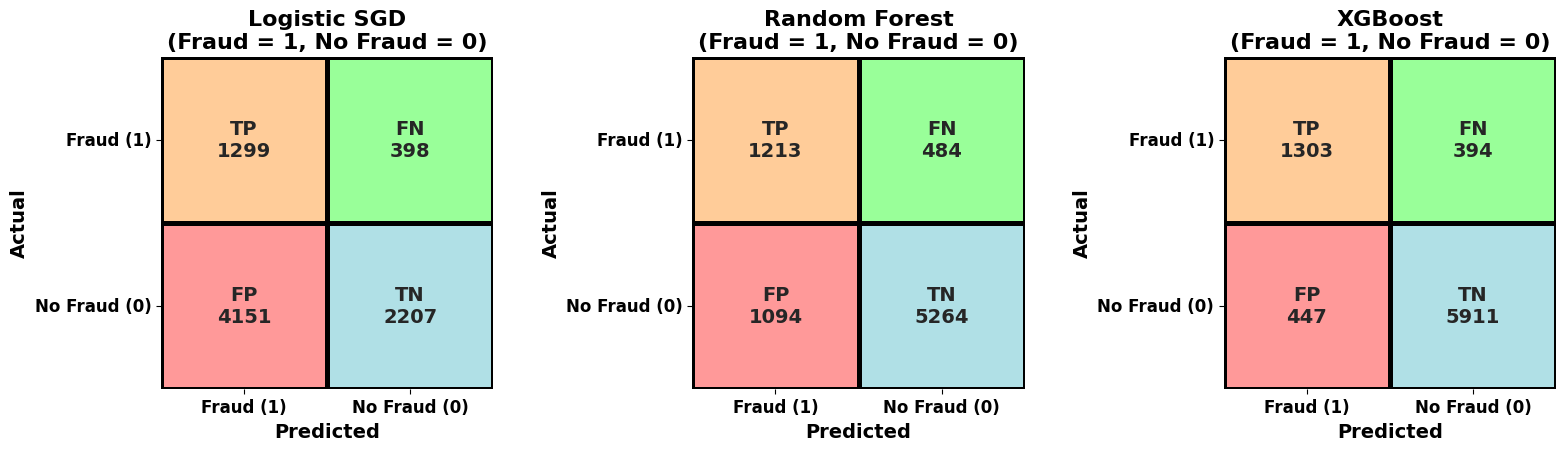

In [ ]:
plot_confusion_matrices(results)

## ROC-AUC Curve

In [ ]:
def plot_roc_curves(results):

    plt.figure(figsize=(8,6))

    for r in results:

        fpr, tpr, _ = roc_curve(r["y_val"], r["y_prob_val"])

        plt.plot(fpr, tpr, label=f"{r['model']} (AUC={r['val_roc_auc']:.3f})")

    plt.plot([0,1],[0,1],'k--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison", fontsize=15, fontweight="bold")
    plt.legend()
    plt.show()

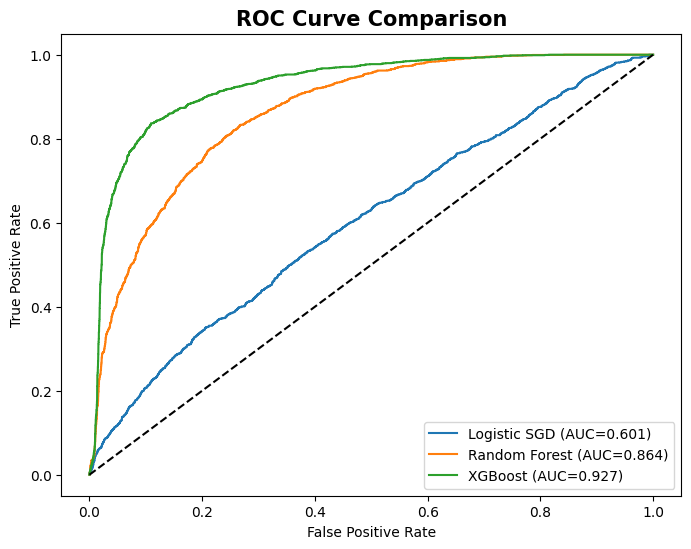

In [ ]:
plot_roc_curves(results)

## Precision–Recall Curve Comparison

In [ ]:


def plot_pr_curves(results):

    plt.figure(figsize=(8,6))

    for r in results:

        precision, recall, _ = precision_recall_curve(
            r["y_val"],
            r["y_prob_val"]
        )

        # Compute F1-score
        f1 = 2 * precision * recall / (precision + recall + 1e-10)

        # Maximum F1-score
        idx = np.argmax(f1)
        max_f1 = f1[idx]

        # Plot PR curve with Max F1 in legend
        plt.plot(
            recall,
            precision,
            linewidth=2,
            label=f'{r["model"]} (Max F1 = {max_f1:.3f})'
        )

        # Highlight the maximum F1 point
        plt.scatter(
            recall[idx],
            precision[idx],
            s=70,
            marker='o'
        )

        # Annotate the value
        plt.text(
            recall[idx],
            precision[idx],
            f'{max_f1:.3f}',
            fontsize=9,
            ha='left',
            va='bottom'
        )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(
        "Precision-Recall Curve",
        fontsize=15,
        fontweight="bold"
    )
    plt.grid(True)
    plt.legend()
    plt.show()

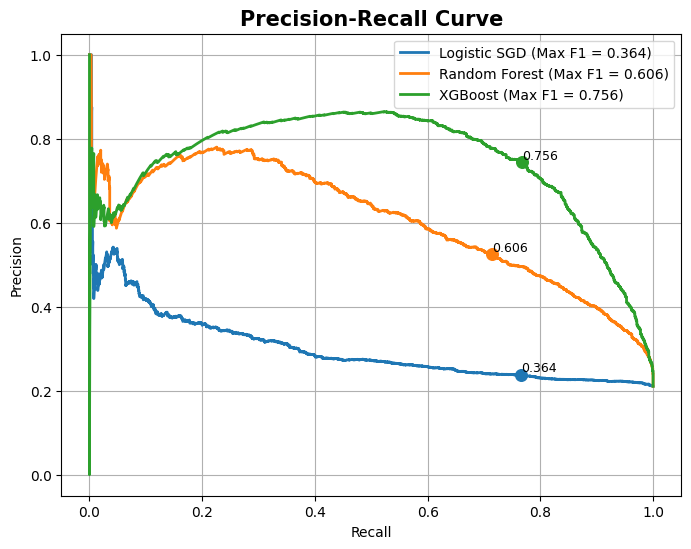

In [ ]:
plot_pr_curves(results)

In [ ]:
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve
)
import matplotlib.pyplot as plt
import numpy as np


def plot_roc_pr_curves(results):

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # ==========================
    # ROC Curve
    # ==========================
    ax = axes[0]

    for r in results:

        fpr, tpr, _ = roc_curve(
            r["y_val"],
            r["y_prob_val"]
        )

        ax.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"{r['model']} (AUC = {r['val_roc_auc']:.3f})"
        )

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)

    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(
        "ROC Curve",
        fontsize=14,
        fontweight="bold"
    )
    ax.grid(True, alpha=0.3)
    ax.legend()


    # ==========================
    # Precision-Recall Curve
    # ==========================
    ax = axes[1]

    for r in results:

        precision, recall, _ = precision_recall_curve(
            r["y_val"],
            r["y_prob_val"]
        )

        f1 = 2 * precision * recall / (precision + recall + 1e-10)

        idx = np.argmax(f1)
        max_f1 = f1[idx]

        ax.plot(
            recall,
            precision,
            linewidth=2,
            label=f"{r['model']} (Max F1 = {max_f1:.3f})"
        )

        ax.scatter(
            recall[idx],
            precision[idx],
            s=60
        )

        ax.text(
            recall[idx],
            precision[idx],
            f"{max_f1:.3f}",
            fontsize=9,
            ha="left",
            va="bottom"
        )

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(
        "Precision-Recall Curve",
        fontsize=14,
        fontweight="bold"
    )
    ax.grid(True, alpha=0.3)
    ax.legend()

    # ==========================
    # Overall Title
    # ==========================
    #fig.suptitle(
    #    "ROC and Precision-Recall Curve Comparison",
    #    fontsize=16,
    #    fontweight="bold"
    #)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

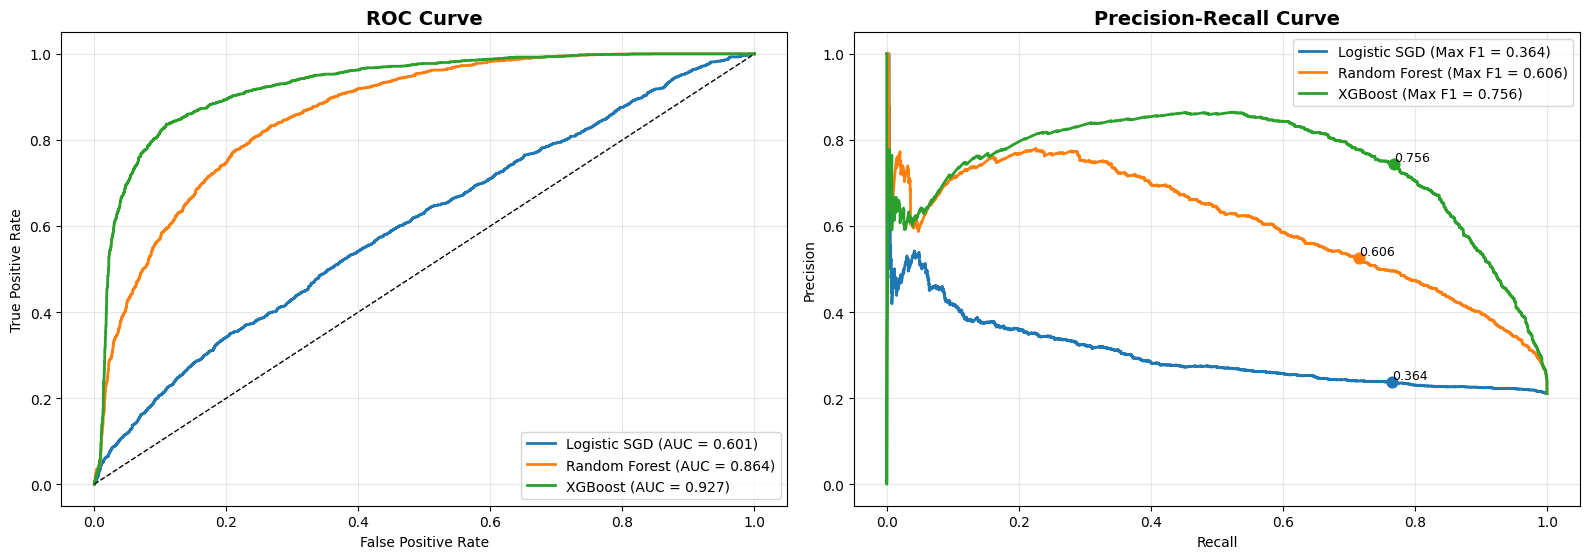

In [ ]:
plot_roc_pr_curves(results)

## Loss Comparison Plot

In [ ]:
loss_df

,model,train_loss,val_loss
0,Logistic SGD,0.632043,0.641029
1,Random Forest,0.414484,0.513343
2,XGBoost,0.153704,0.327655


In [ ]:
def plot_loss_comparison(results):

    models = [r["model"] for r in results]
    train_loss = [r["train_loss"] for r in results]
    val_loss = [r["val_loss"] for r in results]

    x = np.arange(len(models))
    width = 0.35

    plt.figure(figsize=(10, 6))

    # Colors
    train_color = "#6A3D9A"
    val_color   = "#FF7F0E"

    # Bars
    plt.bar(x - width/2, train_loss, width, label="Train Loss", color=train_color)
    plt.bar(x + width/2, val_loss, width, label="Validation Loss", color=val_color)

    # Labels
    plt.xticks(x, models, fontsize=11)
    plt.xlabel("Models", fontsize=13, fontweight="bold")
    plt.ylabel("Loss", fontsize=13, fontweight="bold")
    #plt.title("Loss Comparison Across Models for Validation Data", fontsize=15, fontweight="bold")

    # Values on top of bars
    for i in range(len(models)):
        plt.text(x[i] - width/2, train_loss[i] + 0.01, f"{train_loss[i]:.3f}", ha='center', fontsize=10)
        plt.text(x[i] + width/2, val_loss[i] + 0.01, f"{val_loss[i]:.3f}", ha='center', fontsize=10)

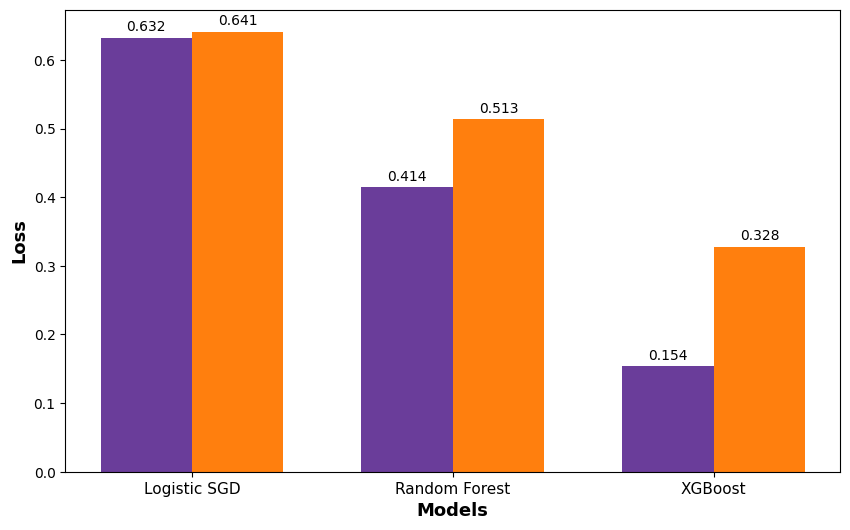

In [ ]:
plot_loss_comparison(results)

# Apply Feature Imporantance on XGBOOST and Random Forest


In [ ]:

def plot_feature_importance_side_by_side(
    xgb_model,
    rf_model,
    feature_names,
    top_n=20,
    figsize=(18, 8)
):

    # XGBoost
    xgb_imp = pd.DataFrame({
        "Feature": feature_names,
        "Importance": xgb_model.feature_importances_
    })

    xgb_imp["Importance"] = (
        xgb_imp["Importance"] /
        xgb_imp["Importance"].sum()
    ) * 100

    xgb_imp = xgb_imp.sort_values(
        "Importance",
        ascending=False
    ).head(top_n)

    # Random Forest
    rf_imp = pd.DataFrame({
        "Feature": feature_names,
        "Importance": rf_model.feature_importances_
    })

    rf_imp["Importance"] = (
        rf_imp["Importance"] /
        rf_imp["Importance"].sum()
    ) * 100

    rf_imp = rf_imp.sort_values(
        "Importance",
        ascending=False
    ).head(top_n)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # -----------------------------
    # XGBoost
    # -----------------------------
    bars = axes[0].barh(
        xgb_imp["Feature"][::-1],
        xgb_imp["Importance"][::-1],
        color="royalblue"
    )

    axes[0].set_title("XGBoost", fontsize=15, fontweight="bold")
    axes[0].set_xlabel("Feature Importance (%)")
    axes[0].grid(axis="x", linestyle="--", alpha=0.4)
    axes[0].set_xlim(0, 6)
    axes[0].set_xticks(np.arange(0, 6, 1))

    for bar in bars:
        width = bar.get_width()
        axes[0].text(
            width + 0.2,
            bar.get_y() + bar.get_height()/2,
            f"{width:.2f}%",
            va="center",
            fontsize=11,
            fontweight="bold"
        )

    # -----------------------------
    # Random Forest
    # -----------------------------
    bars = axes[1].barh(
        rf_imp["Feature"][::-1],
        rf_imp["Importance"][::-1],
        color="forestgreen"
    )

    axes[1].set_title("Random Forest", fontsize=15, fontweight="bold")
    axes[1].set_xlabel("Feature Importance (%)")
    axes[1].grid(axis="x", linestyle="--", alpha=0.4)
    axes[1].set_xlim(0, 12)
    axes[1].set_xticks(np.arange(0, 29, 2))

    for bar in bars:
        width = bar.get_width()
        axes[1].text(
            width + 0.1,
            bar.get_y() + bar.get_height()/2,
            f"{width:.2f}%",
            va="center",
            fontsize=11,
            fontweight="bold"
        )
    #fig.suptitle(
    #    "Feature Importance Across Models for Validation Data",
    #    fontsize=15,
    #    fontweight="bold",
    #    y=1.   # Moves title upward
    #)
    plt.tight_layout()
    plt.show()

    return xgb_imp, rf_imp

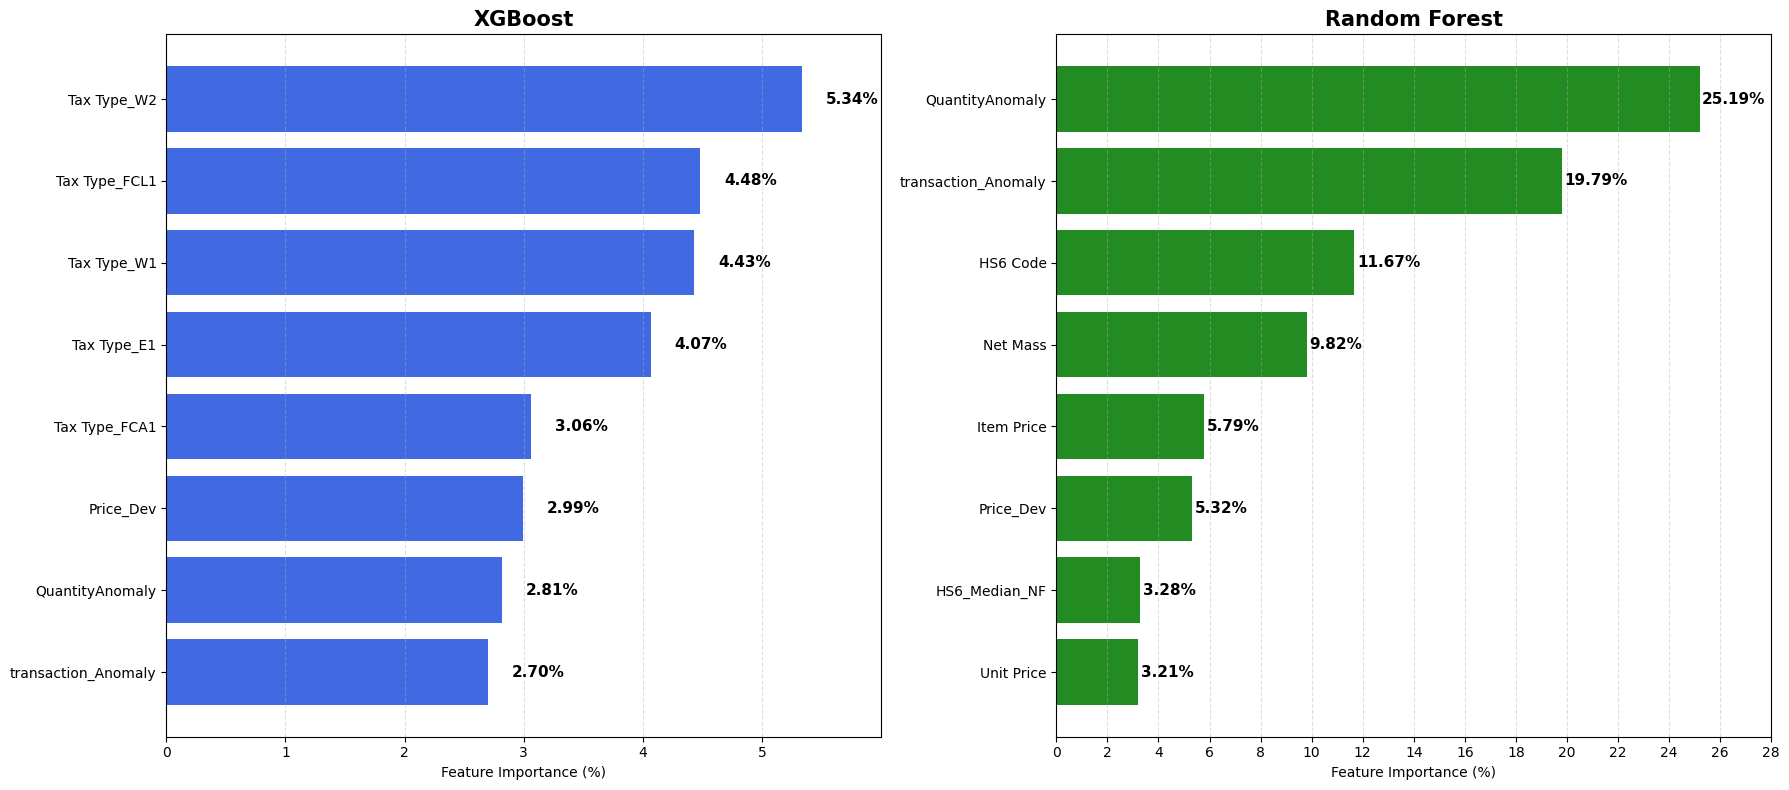

In [ ]:
xgb_imp, rf_imp = plot_feature_importance_side_by_side(
    xgb_model,
    rf_model,
    X_train_transformed.columns,
    top_n=8
)

# Apply Shap

In [ ]:
def plot_shap_summary(model, X_val, dataset_name, max_display, model_name="XGBoost"):

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_val)

    plt.figure(figsize=(10, 6))

    shap.summary_plot(
        shap_values,
        X_val,
        max_display=max_display,
        show=False
    )

    #plt.title(f"{model_name} SHAP Summary Plot Over {dataset_name}")
    plt.xlabel("SHAP Value (Class 1 (Fraud) > 0 & Class 0 (Fraud) < 0)")
    plt.ylabel("Features (with Intensity)")
    plt.tight_layout()
    plt.show()

#### SHAP OUTPUT TRAIN AND VAL

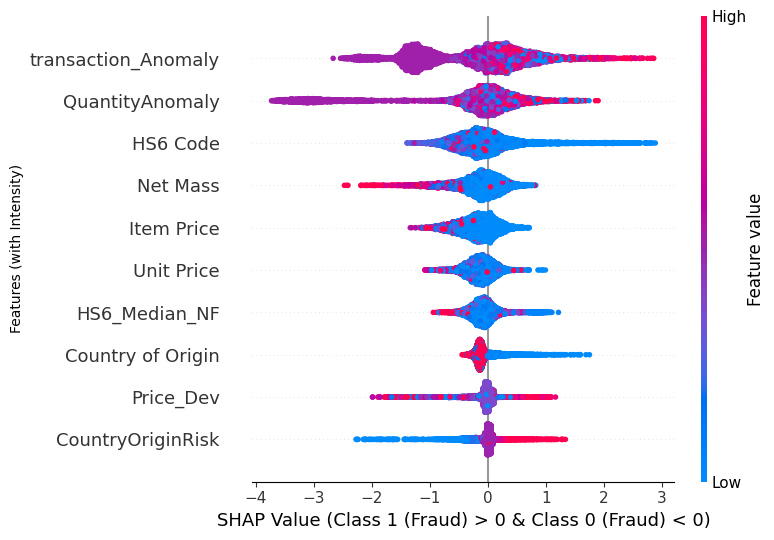

In [ ]:
plot_shap_summary(
    model=xgb_model,
    X_val=X_val_transformed,
    dataset_name="Validation Data",
    max_display= 10,
    model_name="XGBoost"
)

In [ ]:
#shap.summary_plot(shap_values, X_val, plot_type="bar")

# Save Models

In [ ]:
def save_models(models_dict, folder_path= None):
    """
    Save multiple models using pickle.

    Parameters:
    models_dict: dict -> {"model_name": model_object}
    folder_path: str -> directory to save models
    """

    os.makedirs(folder_path, exist_ok=True)

    for name, model in models_dict.items():
        file_path = os.path.join(folder_path, f"{name}.pkl")

        with open(file_path, "wb") as f:
            pickle.dump(model, f)

        print(f"Saved: {name} -> {file_path}")

In [ ]:
model_path = "/content/drive/MyDrive/PMAIDE/Sem-1/Machine Learning/Lab/Project/Final Project/saved_models"

In [ ]:
models_to_save = {
    "logistic_sgd": reg_logistic_regression_intercept,
    "random_forest": rf_model,
    "xgboost": xgb_model
}

save_models(models_to_save, model_path)

Saved: logistic_sgd -> /content/drive/MyDrive/PMAIDE/Sem-1/Machine Learning/Lab/Project/Final Project/saved_models/logistic_sgd.pkl
Saved: random_forest -> /content/drive/MyDrive/PMAIDE/Sem-1/Machine Learning/Lab/Project/Final Project/saved_models/random_forest.pkl
Saved: xgboost -> /content/drive/MyDrive/PMAIDE/Sem-1/Machine Learning/Lab/Project/Final Project/saved_models/xgboost.pkl


# Model Prediction with Unseen Data

In [ ]:
# Evaluated during training with validation data
final_thresholds = {
    "Logistic Regression SGD": 0.427684,
    "Random Forest Classifier": 0.569847,
    "XGBoost Classifier": 0.573820
}



## Load Model

In [ ]:
def load_model(model_path):
    with open(model_path, "rb") as f:
        model = pickle.load(f)
        print("Loaded Successfully")
    return model

In [ ]:
log_model_pk = load_model("/content/drive/MyDrive/PMAIDE/Sem-1/Machine Learning/Lab/Project/Final Project/saved_models/logistic_sgd.pkl")
rf_model_pk = load_model("/content/drive/MyDrive/PMAIDE/Sem-1/Machine Learning/Lab/Project/Final Project/saved_models/random_forest.pkl")
xgb_model_pk = load_model("/content/drive/MyDrive/PMAIDE/Sem-1/Machine Learning/Lab/Project/Final Project/saved_models/xgboost.pkl")

Loaded Successfully
Loaded Successfully
Loaded Successfully


In [ ]:
models = {
    "Logistic Regression SGD": log_model_pk,
    "Random Forest Classifier": rf_model_pk,
    "XGBoost Classifier": xgb_model_pk
}

## Model Evaluation

In [ ]:

def evaluate_models(
    models,
    thresholds,
    X_val,
    y_val,
    X_test,
    y_test
):

    metrics = []

    datasets = {
        "Validation": (X_val, y_val),
        "Test": (X_test, y_test)
    }

    for dataset_name, (X, y) in datasets.items():

        for model_name, model in models.items():

            threshold = thresholds[model_name]

            # Predicted probabilities
            y_prob = model.predict_proba(X)[:, 1]

            # Predicted class
            y_pred = (y_prob >= threshold).astype(int)

            metrics.append({

                "Model": model_name,
                "Dataset": dataset_name,
                "Threshold": threshold,


                "Accuracy": accuracy_score(y, y_pred),
                "Precision": precision_score(y, y_pred),
                "Recall": recall_score(y, y_pred),
                "F1-score": f1_score(y, y_pred),
                "ROC-AUC": roc_auc_score(y, y_prob),
                "Loss": log_loss(y, y_prob)

            })

    metrics_df = pd.DataFrame(metrics)

    return metrics_df

In [ ]:
metrics_df = evaluate_models(

    models,
    final_thresholds,

    X_val_transformed,
    y_val,

    X_test_transformed,
    y_test

)

In [ ]:
print("Model Comparision with Val and Test Data: \n")
compare_df = metrics_df
compare_df

Model Comparision with Val and Test Data: 



,Model,Dataset,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,Loss
0,Logistic Regression SGD,Validation,0.427684,0.435133,0.238209,0.764879,0.363280,0.601178,0.641029
1,Random Forest Classifier,Validation,0.569847,0.803724,0.525174,0.713023,0.604849,0.863516,0.513343
2,XGBoost Classifier,Validation,0.573820,0.895593,0.744571,0.767826,0.756020,0.927306,0.327655
3,Logistic Regression SGD,Test,0.427684,0.429862,0.239271,0.750962,0.362912,0.584695,0.635419
4,Random Forest Classifier,Test,0.569847,0.792439,0.515330,0.674546,0.584286,0.846668,0.525691
5,XGBoost Classifier,Test,0.573820,0.886591,0.729687,0.755360,0.742301,0.919611,0.344951


In [ ]:
def prediction_table(
    model,
    X,
    y,
    threshold,
    model_name,
    top_n=10
):

    y_prob = model.predict_proba(X)[:,1]

    y_pred = (y_prob >= threshold).astype(int)

    pred_df = pd.DataFrame({

        "Actual": np.where(
            y==1,
            "Fraud (1)",
            "No Fraud (0)"
        ),

        "Predicted": np.where(
            y_pred==1,
            "Fraud (1)",
            "No Fraud (0)"
        ),

        "Probability of Fraud": np.round(y_prob,4)

    })

    print("="*70)
    print(model_name)
    print("="*70)

    return pred_df

In [ ]:
predect_test_data= prediction_table(
        xgb_model_pk,
        X_test_transformed,
        y_test,
        final_thresholds["XGBoost Classifier"],
        "XGBoost Classifier Prediction Over Unseen/Test Data"
    )
predect_test_data

XGBoost Classifier Prediction Over Unseen/Test Data


,Actual,Predicted,Probability of Fraud
0,No Fraud (0),No Fraud (0),0.1731
1,No Fraud (0),No Fraud (0),0.4195
2,No Fraud (0),No Fraud (0),0.0085
3,No Fraud (0),No Fraud (0),0.1705
4,No Fraud (0),No Fraud (0),0.0016
...,...,...,...
8407,No Fraud (0),No Fraud (0),0.5144
8408,No Fraud (0),Fraud (1),0.5796
8409,No Fraud (0),Fraud (1),0.9984
8410,No Fraud (0),No Fraud (0),0.2196


In [ ]:
compare_df.columns

Index(['Model', 'Dataset', 'Threshold', 'Accuracy', 'Precision', 'Recall',
       'F1-score', 'ROC-AUC', 'Loss'],
      dtype='object')

In [ ]:


def plot_metrics(compare_df):
    # 1. Define the 6 metrics matching your DataFrame columns exactly
    metrics = [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "Loss"
    ]

    # Nice colors for Validation vs Test
    colors = ["#4E79A7", "#E15759"]  # Blue, Red

    # 2. Create a 2x3 grid (exactly 6 slots for our 6 metrics)
    fig, axes = plt.subplots(
        2,
        3,
        figsize=(20, 12)
    )
    axes = axes.flatten()

    # 3. Loop through and plot each metric
    for i, metric in enumerate(metrics):
        ax = axes[i]

        # Reshape data for side-by-side grouped bars
        pivot = compare_df.pivot(
            index="Model",
            columns="Dataset",
            values=metric
        )

        pivot.plot(
            kind="bar",
            ax=ax,
            color=colors,
            width=0.75,
            edgecolor="black"
        )

        # Title and Labels
        ax.set_title(
            metric,
            fontsize=16,
            fontweight="bold"
        )
        ax.set_xlabel("")
        ax.set_ylabel(
            "Score",
            fontsize=13,
            fontweight="bold"
        )

        # Formatting X & Y Axes
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
        ax.set_ylim(0, 1.05)

        ax.tick_params(axis="x", rotation=15, labelsize=11)
        ax.tick_params(axis="y", labelsize=11)

        # Subtle background grid lines
        ax.grid(
            axis="y",
            linestyle="--",
            alpha=0.4
        )

        # Add data value labels on top of each bar
        for container in ax.containers:
            ax.bar_label(
                container,
                labels=[f"{v.get_height()*100:.2f}%" for v in container],
                fontsize=11,
                fontweight="bold",
                padding=3
            )

        # Show legend only on the first chart to avoid clutter
        if i == 0:
            ax.legend(
                title="Dataset",
                fontsize=11,
                title_fontsize=12
            )
        else:
            if ax.get_legend() is not None:
                ax.get_legend().remove()

    # 4. Clean up any unused subplots (Safe Guardrail)
    # Since len(metrics) == 6 and len(axes) == 6, this won't delete anything now.
    # If you change to 5 metrics down the road, it will cleanly wipe out the 6th slot.
    for j in range(len(metrics), len(axes)):
        fig.delaxes(axes[j])

    # Main Figure Title
    #fig.suptitle(
    #   "Model Performance Across Test/Unseen Datasets",
    #   fontsize=20,
    #   fontweight="bold",
    #   y=0.98
    #

    plt.tight_layout()
    plt.show()



In [ ]:
compare_df.columns

Index(['Model', 'Dataset', 'Threshold', 'Accuracy', 'Precision', 'Recall',
       'F1-score', 'ROC-AUC', 'Loss'],
      dtype='object')

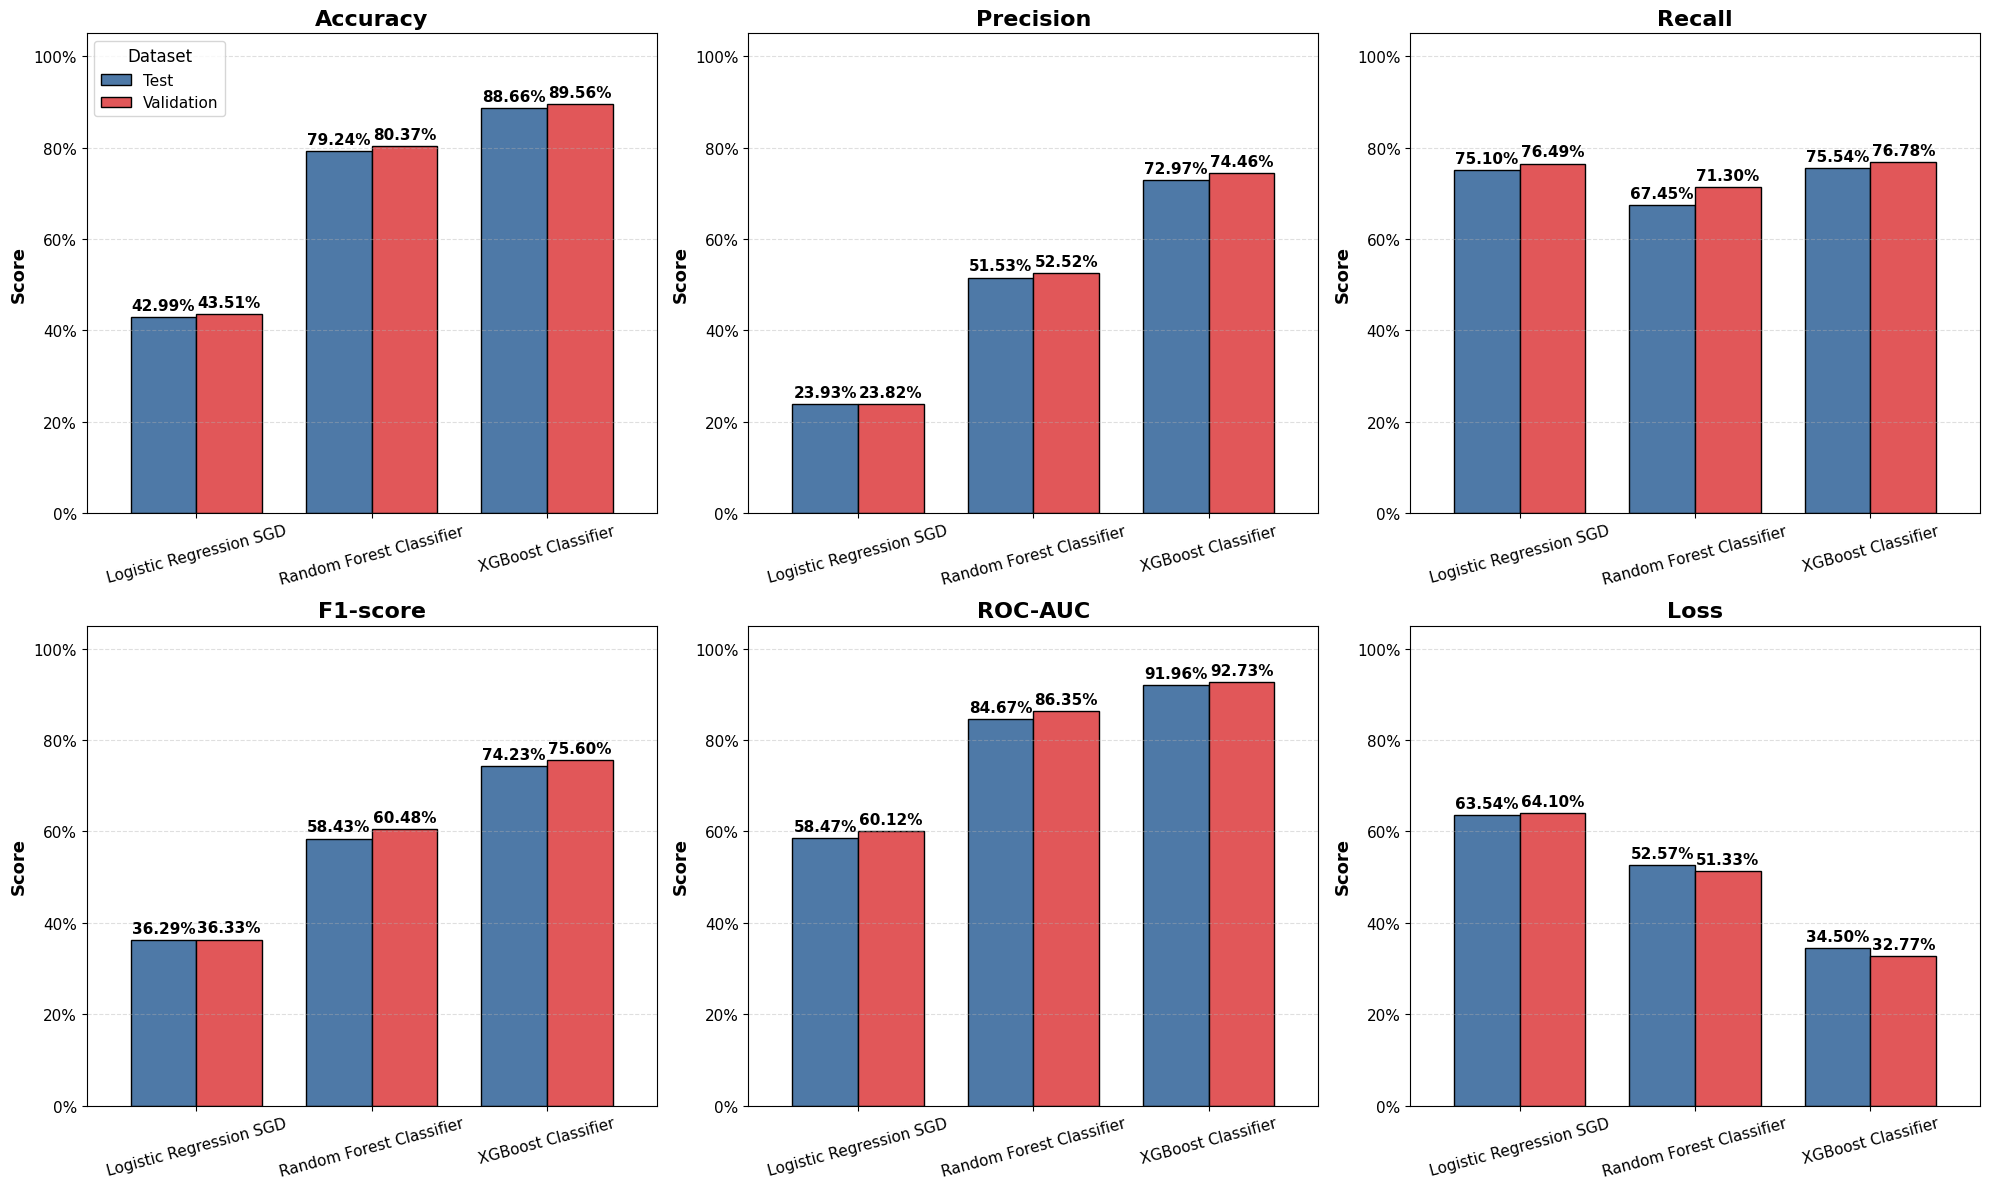

In [ ]:
plot_metrics(compare_df)

In [ ]:
compare_df.to_csv("compare_df_v1.csv", index=False)

# Comparision of Train, Test, Val

In [ ]:
import pandas as pd
import os
imp

In [ ]:
path

NameError: name 'path' is not defined

In [ ]:

path="/content/drive/MyDrive/PMAIDE/Sem-1/Machine Learning/Lab/Project/datasets"
compare_train_val_test_df =pd.read_csv(path+"/compare_train_test_val.csv")

compare_train_val_test_df

,Model,Dataset,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,Loss
0,Logistic Regression SGD,Train,0.427684,0.435000,0.245100,0.766100,0.371400,0.599700,0.632043
1,Random Forest Classifier,Train,0.569847,0.863600,0.660300,0.770400,0.711100,0.927900,0.414484
2,XGBoost Classifier,Train,0.573820,0.981100,0.953700,0.959700,0.956700,0.997500,0.153704
3,Logistic Regression SGD,Validation,0.427684,0.435133,0.238209,0.764879,0.363280,0.601178,0.641029
4,Random Forest Classifier,Validation,0.569847,0.803724,0.525174,0.713023,0.604849,0.863516,0.513343
5,XGBoost Classifier,Validation,0.573820,0.895593,0.744571,0.767826,0.756020,0.927306,0.327655
6,Logistic Regression SGD,Test,0.427684,0.429862,0.239271,0.750962,0.362912,0.584695,0.635419
7,Random Forest Classifier,Test,0.569847,0.792439,0.515330,0.674546,0.584286,0.846668,0.525691
8,XGBoost Classifier,Test,0.573820,0.886591,0.729687,0.755360,0.742301,0.919611,0.344951


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


def plot_metrics_final_compare(compare_train_val_test_df):

    # Metrics to plot
    metrics = [
        "Accuracy",
        "Loss",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
    ]

    # Dataset order
    dataset_order = ["Train", "Test", "Validation"]

    # Colors
    colors = [
        "#4E79A7",  # Train
        "#59A14F",  # Test
        "#E15759",  # Validation
    ]

    # Create figure
    fig, axes = plt.subplots(
        2,
        3,
        figsize=(36, 22)
    )

    axes = axes.flatten()

    # Plot each metric
    for i, metric in enumerate(metrics):

        ax = axes[i]

        # Pivot and enforce dataset order
        pivot = (
            compare_train_val_test_df
            .pivot(
                index="Model",
                columns="Dataset",
                values=metric
            )
            .reindex(columns=dataset_order)
        )

        # Plot grouped bar chart
        pivot.plot(
            kind="bar",
            ax=ax,
            color=colors,
            width=0.75,
            edgecolor="black"
        )

        # Title
        ax.set_title(
            metric,
            fontsize=24,
            fontweight="bold",
            pad=15
        )

        # Axis labels
        ax.set_xlabel("")

        ax.set_ylabel(
            "Score",
            fontsize=22,
            fontweight="bold"
        )

        # Percentage format
        ax.yaxis.set_major_formatter(
            PercentFormatter(
                xmax=1,
                decimals=0
            )
        )

        ax.set_ylim(0, 1.20)

        # Tick size
        ax.tick_params(
            axis="x",
            rotation=20,
            labelsize=18
        )

        ax.tick_params(
            axis="y",
            labelsize=18
        )

        # Grid
        ax.grid(
            axis="y",
            linestyle="--",
            linewidth=1,
            alpha=0.4
        )

        # Add value labels
        for container in ax.containers:

            labels = ax.bar_label(
                container,
                labels=[
                    f"{bar.get_height()*100:.2f}%"
                    for bar in container
                ],
                fontsize=22,
                fontweight="bold",
                padding=5
            )

            for label in labels:
                label.set_rotation(90)
                label.set_ha("center")
                label.set_va("bottom")


        # Legend only on first graph
        if i == 0:

            ax.legend(
                title="Dataset",
                loc="upper left",
                bbox_to_anchor=(0.01, 0.99),
                fontsize=18,
                title_fontsize=20,
                frameon=True
            )

        else:

            if ax.get_legend() is not None:
                ax.get_legend().remove()


    # Remove unused subplots
    for j in range(len(metrics), len(axes)):
        fig.delaxes(axes[j])


    # Layout adjustment
    plt.subplots_adjust(
        left=0.05,
        right=0.98,
        top=0.95,
        bottom=0.08,
        wspace=0.25,
        hspace=0.25
    )

    plt.show()

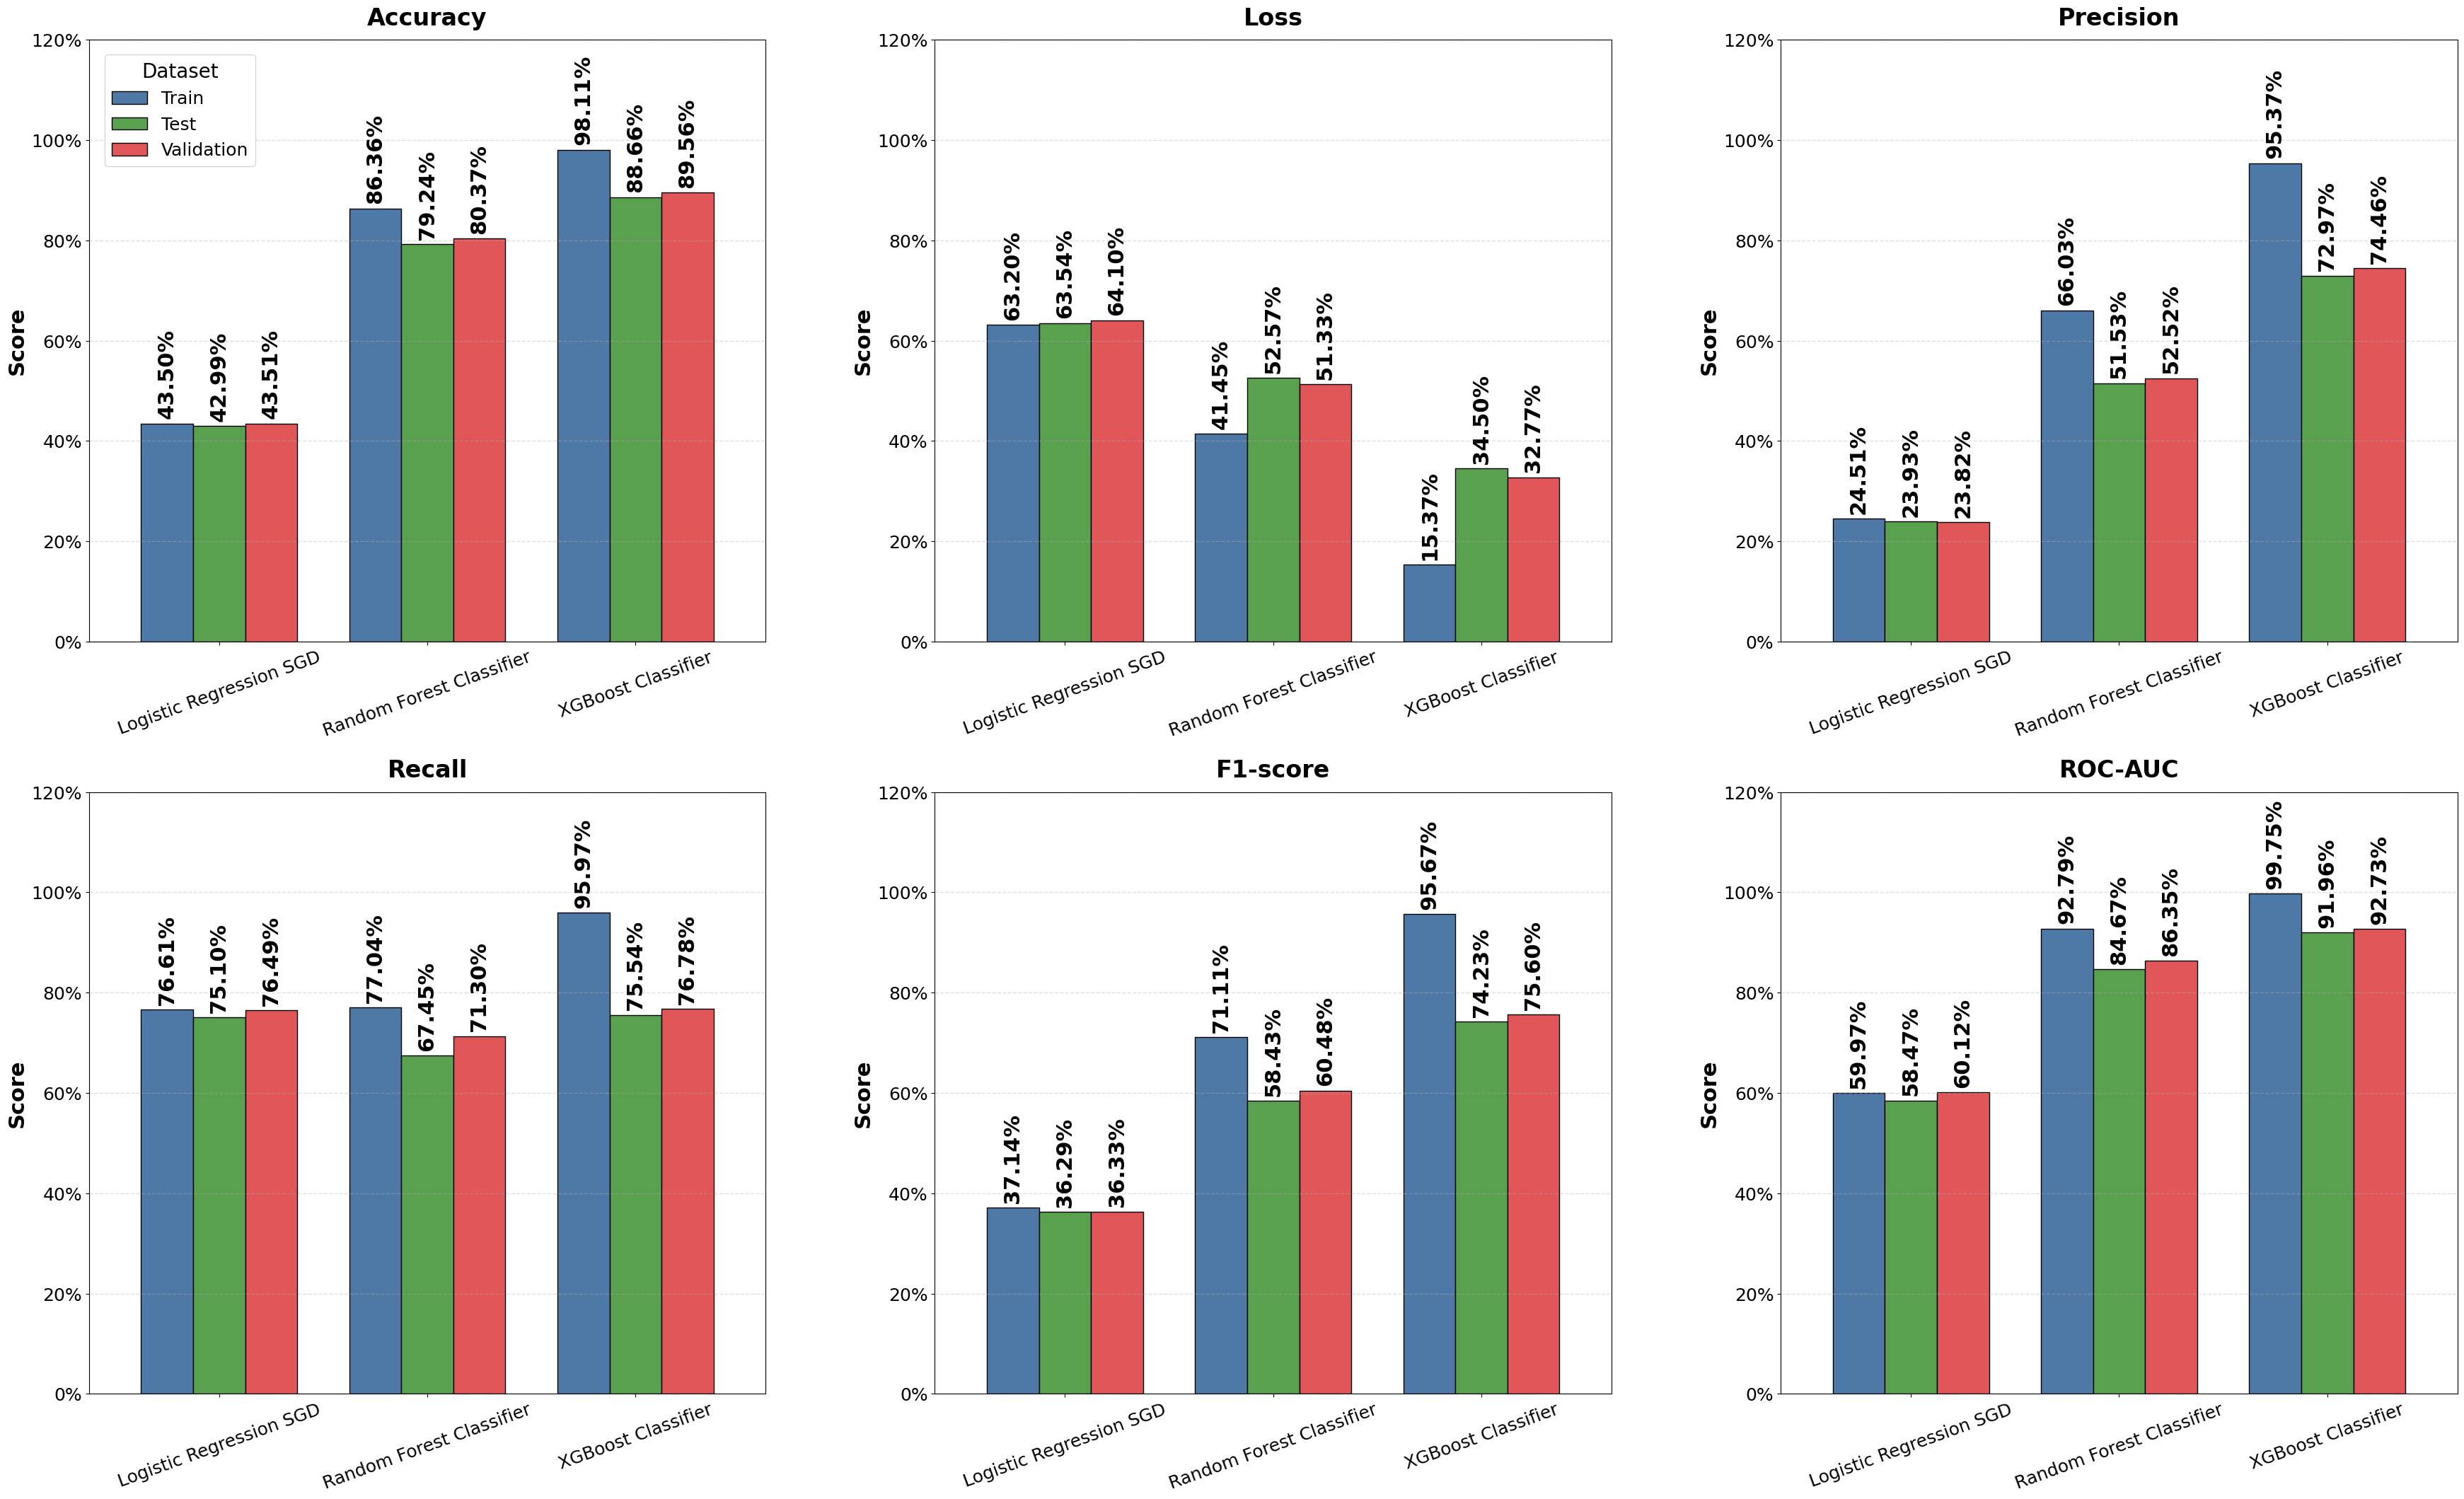

In [ ]:
plot_metrics_final_compare(compare_train_val_test_df)

In [ ]:
compare_train_val_test_df.head(12)

,Model,Dataset,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,Loss
0,Logistic Regression SGD,Train,0.427684,0.435000,0.245100,0.766100,0.371400,0.599700,0.632043
1,Random Forest Classifier,Train,0.569847,0.863600,0.660300,0.770400,0.711100,0.927900,0.414484
2,XGBoost Classifier,Train,0.573820,0.981100,0.953700,0.959700,0.956700,0.997500,0.153704
3,Logistic Regression SGD,Validation,0.427684,0.435133,0.238209,0.764879,0.363280,0.601178,0.641029
4,Random Forest Classifier,Validation,0.569847,0.803724,0.525174,0.713023,0.604849,0.863516,0.513343


# Manual Test

```
Price_Dev=log(HS6_Median_NFUnitPrice​)
```

In [ ]:
df_trainset.head()

,Declaration ID,Date,Office ID,Process Type,Import Type,Import Use,Payment Type,Mode of Transport,Declarant ID,Importer ID,...,Critical Fraud,Year_Month,FreqTransactions,Unit Price,HS6_Median_NF,Price_Dev,QuantityAnomaly,transaction_Anomaly,CountryOriginRisk,CountryDepartureRisk
0,97061800,2020-01-01,30,B,11,21,11,10,ZZR1LT6,QLRUBN9,...,0,2020-01,1,3446.8,2003.1,5.427503e-01,-5.115162,0.000000,-0.782758,-1.419516
1,85945189,2020-01-01,40,B,11,21,11,40,SWF9S4X,7JD1S2X,...,0,2020-01,2,33.1,33.1,0.000000e+00,-0.763528,-0.763528,-1.250703,-1.306169
2,77854751,2020-01-01,20,B,11,21,11,40,X4XT6P8,WI9O3I5,...,0,2020-01,2,258.6,258.6,0.000000e+00,-1.218362,-1.218362,-1.250703,-1.306169
3,46925060,2020-01-01,40,B,11,21,43,40,K7LCQTZ,6LI9721,...,0,2020-01,1,160.3,160.3,-2.220446e-16,0.560172,-0.142992,-1.322246,-1.433854
4,34131149,2020-01-01,20,B,11,21,11,10,1HMVIVH,RZ871V1,...,0,2020-01,1,265.2,265.2,0.000000e+00,-0.916291,-0.693147,-1.322246,-1.433854


In [ ]:
under_over_label_train_df = df_trainset.copy()

under_over_label_train_df = under_over_label_train_df[
    [
        'HS6 Code',
        'Unit Price',
        'HS6_Median_NF',
        'Price_Dev',
        'Fraud'
    ]
]

under_over_label_train_df.head()

,HS6 Code,Unit Price,HS6_Median_NF,Price_Dev,Fraud
0,440890,3446.8,2003.1,5.427503e-01,0
1,690722,33.1,33.1,0.000000e+00,0
2,620822,258.6,258.6,0.000000e+00,0
3,940350,160.3,160.3,-2.220446e-16,0
4,71080,265.2,265.2,0.000000e+00,0


## Interpretation

The **Price Deviation** feature is computed as

$$
\text{Price\_Dev} =
\ln\left(
\frac{\text{Unit Price}}
{\text{HS6 Median}_{\mathrm{NF}}}
\right)
$$

where:

- **Unit Price** is the declared price per unit.
- **HS6 Median$_{\mathrm{NF}}$** is the median unit price of legitimate (**non-fraud**) transactions within the same HS6 code.

Since `Price_Dev` is expressed in the logarithmic domain, the thresholds can be converted back into **price ratios** using the exponential function.

### Under Invoice

The lower threshold is

$$
\text{Price\_Dev} = -0.7842
$$

Converting back to the original price scale,

$$
e^{-0.7842} \approx 0.456
$$

This implies that

$$
\text{Unit Price} < 0.456 \times \text{HS6 Median}_{\mathrm{NF}}
$$

In other words, the declared unit price is **less than 45.6% of the expected HS6 non-fraud median price**, corresponding to approximately **54.4% below** the expected market value.

---

### Over Invoice

The upper threshold is

$$
\text{Price\_Dev} = 1.3690
$$

Converting back,

$$
e^{1.3690} \approx 3.93
$$

This implies that

$$
\text{Unit Price} > 3.93 \times \text{HS6 Median}_{\mathrm{NF}}
$$

In other words, the declared unit price is **more than 3.93 times** the expected HS6 non-fraud median price, corresponding to approximately **293% above** the expected market value.

---

### Invoice Labeling Criteria

The invoice labels are assigned as follows:

- **Normal:** `Fraud = 0`
- **Under Invoice:** `Fraud = 1` and `Price_Dev < -0.7842`
- **Over Invoice:** `Fraud = 1` and `Price_Dev > 1.3690`
- **Price Consistent Fraud:** `Fraud = 1` and $-0.7842 \leq \text{Price\_Dev} \leq 1.3690$

The threshold values were obtained from the **5th and 95th percentiles** of the `Price_Dev` distribution calculated from legitimate (non-fraud) transactions.

In [ ]:
print(
    under_over_label_train_df.loc[
        under_over_label_train_df["Fraud"] == 1,
        "Price_Dev"
    ].quantile([0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99])
)

0.01   -4.007471e+00
0.05   -1.515843e+00
0.10   -4.849334e-03
0.25    0.000000e+00
0.50    0.000000e+00
0.75    2.220446e-16
0.90    1.375088e+00
0.95    2.437449e+00
0.99    3.963983e+00
Name: Price_Dev, dtype: float64


In [ ]:

def create_invoice_labels(df):

    # Learn thresholds from non-fraud records
    normal_price_dev = df.loc[df["Fraud"] == 0, "Price_Dev"]

    UNDER_TH = normal_price_dev.quantile(0.05)
    OVER_TH  = normal_price_dev.quantile(0.95)

    print(f"Under Invoice Threshold : {UNDER_TH:.20f}")
    print(f"Over Invoice Threshold  : {OVER_TH:.4f}")

    # Default label
    df["Invoice_Label"] = "Normal"

    fraud = df["Fraud"] == 1

    # Under Invoice
    df.loc[
        fraud & (df["Price_Dev"] < UNDER_TH),
        "Invoice_Label"
    ] = "Under Invoice"

    # Over Invoice
    df.loc[
        fraud & (df["Price_Dev"] > OVER_TH),
        "Invoice_Label"
    ] = "Over Invoice"

    # Price Consistent Fraud
    df.loc[
        fraud &
        (df["Price_Dev"] >= UNDER_TH) &
        (df["Price_Dev"] <= OVER_TH),
        "Invoice_Label"
    ] = "Price Consistent Fraud"

    return df

In [ ]:
under_over_label_train_df = create_invoice_labels(under_over_label_train_df)

Under Invoice Threshold : -0.78421535824518950886
Over Invoice Threshold  : 1.3690


In [ ]:
under_over_label_train_df[under_over_label_train_df['Invoice_Label']=="Under Invoice"]

,HS6 Code,Unit Price,HS6_Median_NF,Price_Dev,Fraud,Invoice_Label
17,852580,455.7,2439.8,-1.677837,1,Under Invoice
58,853690,39.2,186.2,-1.558145,1,Under Invoice
174,853710,25.8,300.5,-2.455073,1,Under Invoice
178,390799,31.3,78.1,-0.914372,1,Under Invoice
236,950300,0.6,66.9,-4.714025,1,Under Invoice
...,...,...,...,...,...,...
37142,841490,32.5,116.6,-1.277509,1,Under Invoice
37199,950300,0.6,66.9,-4.714025,1,Under Invoice
37215,841490,32.5,116.6,-1.277509,1,Under Invoice
37218,850440,27.1,218.0,-2.084961,1,Under Invoice


In [ ]:
under_over_label_train_df["Invoice_Label"].value_counts()

,count
Invoice_Label,
Normal,28960
Price Consistent Fraud,6720
Over Invoice,811
Under Invoice,536


In [ ]:
under_over_label_train_df[under_over_label_train_df["Invoice_Label"]!= "Price Consistent Fraud"]

,HS6 Code,Unit Price,HS6_Median_NF,Price_Dev,Fraud,Invoice_Label
0,440890,3446.8,2003.1,5.427503e-01,0,Normal
1,690722,33.1,33.1,0.000000e+00,0,Normal
2,620822,258.6,258.6,0.000000e+00,0,Normal
3,940350,160.3,160.3,-2.220446e-16,0,Normal
4,71080,265.2,265.2,0.000000e+00,0,Normal
...,...,...,...,...,...,...
37378,392690,0.6,0.6,0.000000e+00,0,Normal
37379,950720,205.8,205.8,0.000000e+00,0,Normal
37382,850440,62.1,218.0,-1.255749e+00,0,Normal
37383,720421,15.2,15.2,2.220446e-16,0,Normal


### Test Data Final Result

In [ ]:
under_over_label_test_df = df_testset.copy()

under_over_label_test_df = under_over_label_test_df[
    [
        'HS6 Code',
        'Unit Price',
        'HS6_Median_NF',
        'Price_Dev',
        'Fraud'
    ]
]

under_over_label_test_df.head()

,HS6 Code,Unit Price,HS6_Median_NF,Price_Dev,Fraud
0,420231,1248.7,1248.7,0.000000e+00,0
1,711311,290.5,290.5,-2.220446e-16,0
2,390690,58.2,58.2,0.000000e+00,0
3,392690,0.6,0.6,0.000000e+00,0
4,871390,2712.8,2712.8,0.000000e+00,0


In [ ]:


def apply_invoice_labels_test(
    df,
    predect_test_data,
    under_th,
    over_th
):
    """
    Apply invoice labels to the test dataset and merge with
    binary prediction results.

    Parameters
    ----------
    under_over_label_test_df : pd.DataFrame
        Test dataset containing Fraud and Price_Dev.

    predect_test_data : pd.DataFrame
        Binary prediction dataframe.

    under_th : float
        Under Invoice threshold learned from training.

    over_th : float
        Over Invoice threshold learned from training.

    Returns
    -------
    pred_df : pd.DataFrame
        Merged dataframe containing predictions and invoice labels.
    """

    # -------------------------
    # Invoice Labels
    # -------------------------
    df["Invoice_Label"] = "Normal"

    fraud = df["Fraud"] == 1

    # Under Invoice
    df.loc[
        fraud & (df["Price_Dev"] < under_th),
        "Invoice_Label"
    ] = "Under Invoice"

    # Over Invoice
    df.loc[
        fraud & (df["Price_Dev"] > over_th),
        "Invoice_Label"
    ] = "Over Invoice"

    # Price Consistent Fraud
    df.loc[
        fraud &
        (df["Price_Dev"] >= under_th) &
        (df["Price_Dev"] <= over_th),
        "Invoice_Label"
    ] = "Price Consistent Fraud"

    # -------------------------
    # Merge with prediction dataframe
    # -------------------------
    pred_df = pd.concat(
    [df.reset_index(drop=True), predect_test_data.reset_index(drop=True)],
    axis=1
)

    return pred_df

In [ ]:
pred_df = apply_invoice_labels_test(
    under_over_label_test_df,
    predect_test_data,
    under_th=-0.7842,
    over_th=1.3690

)


In [ ]:
pred_df['Invoice_Label'].value_counts()

,count
Invoice_Label,
Normal,6593
Price Consistent Fraud,1547
Over Invoice,158
Under Invoice,114


In [ ]:
pred_df.head(3)

,HS6 Code,Unit Price,HS6_Median_NF,Price_Dev,Fraud,Invoice_Label,Actual,Predicted,Probability of Fraud
0,420231,1248.7,1248.7,0.000000e+00,0,Normal,No Fraud (0),No Fraud (0),0.1731
1,711311,290.5,290.5,-2.220446e-16,0,Normal,No Fraud (0),No Fraud (0),0.4195
2,390690,58.2,58.2,0.000000e+00,0,Normal,No Fraud (0),No Fraud (0),0.0085


In [ ]:
filter_pred_df = pred_df[(pred_df['Actual']=="No Fraud (0)") & (pred_df['Predicted']=="No Fraud (0)") & (pred_df['Invoice_Label']=="Normal")
|(pred_df['Actual']=="Fraud (1)") & (pred_df['Predicted']=="Fraud (1)") & (pred_df['Invoice_Label']=="Under Invoice")
|(pred_df['Actual']=="Fraud (1)") & (pred_df['Predicted']=="Fraud (1)") & (pred_df['Invoice_Label']=="Over Invoice")]
#|(pred_df['Actual']=="Fraud (1)") & (pred_df['Predicted']=="Fraud (1)") & (pred_df['Invoice_Label']=="Price Consistent Fraud")

### Final Table

In [ ]:
filter_pred_df.head()

,HS6 Code,Unit Price,HS6_Median_NF,Price_Dev,Fraud,Invoice_Label,Actual,Predicted,Probability of Fraud
0,420231,1248.7,1248.7,0.000000e+00,0,Normal,No Fraud (0),No Fraud (0),0.1731
1,711311,290.5,290.5,-2.220446e-16,0,Normal,No Fraud (0),No Fraud (0),0.4195
2,390690,58.2,58.2,0.000000e+00,0,Normal,No Fraud (0),No Fraud (0),0.0085
3,392690,0.6,0.6,0.000000e+00,0,Normal,No Fraud (0),No Fraud (0),0.1705
4,871390,2712.8,2712.8,0.000000e+00,0,Normal,No Fraud (0),No Fraud (0),0.0016


In [ ]:
sample_test_final_df = (
    filter_pred_df
    .groupby("Invoice_Label", group_keys=False)
    .head(3)
)

#sample_df

#sample_df = pd.concat([
    #filter_pred_df[filter_pred_df["Invoice_Label"] == "Normal"].head(3),
    #filter_pred_df[filter_pred_df["Invoice_Label"] == "Under Invoice"].head(3),
    #filter_pred_df[filter_pred_df["Invoice_Label"] == "Over Invoice"].head(3),
#])

sample_test_final_df.head(9)

,HS6 Code,Unit Price,HS6_Median_NF,Price_Dev,Fraud,Invoice_Label,Actual,Predicted,Probability of Fraud
0,420231,1248.7,1248.7,0.000000e+00,0,Normal,No Fraud (0),No Fraud (0),0.1731
1,711311,290.5,290.5,-2.220446e-16,0,Normal,No Fraud (0),No Fraud (0),0.4195
2,390690,58.2,58.2,0.000000e+00,0,Normal,No Fraud (0),No Fraud (0),0.0085
69,871160,340.6,829.5,-8.901143e-01,1,Under Invoice,Fraud (1),Fraud (1),0.8653
75,901730,448.8,8779.8,-2.973632e+00,1,Under Invoice,Fraud (1),Fraud (1),0.8909
93,940330,1.0,56.2,-4.028917e+00,1,Under Invoice,Fraud (1),Fraud (1),0.9559
165,851829,1093.8,95.2,2.441433e+00,1,Over Invoice,Fraud (1),Fraud (1),0.9745
236,390461,1078.0,124.8,2.156150e+00,1,Over Invoice,Fraud (1),Fraud (1),0.9960
458,871690,410.7,88.6,1.533731e+00,1,Over Invoice,Fraud (1),Fraud (1),0.9659
